<div align="center">

# 🩺 Patient Segmentation using Unsupervised Machine Learning
### A Clustering-Based Analysis of the NHANES Health & Nutrition Survey

---

**Master's Level Machine Learning — Mini Project**

</div>

| | |
|---|---|
| **Project Title** | Patient Segmentation using Unsupervised Machine Learning on NHANES Data |
| **Student Name** | Syed Khaja Irfan Uddin |
| **University** | PES University |
| **Course** | Unsupervised Machine Learning / Machine Learning (Master's) |
| **Project Objective** | Discover clinically meaningful patient sub-populations ("segments") from demographic, dietary, and laboratory data using clustering algorithms, and translate them into actionable healthcare insights. |
| **Dataset** | National Health and Nutrition Examination Survey (NHANES), NCHS / CDC |
| **Software Used** | Python 3, Jupyter Notebook |
| **Primary Metric** | Silhouette Score |
| **Dimensionality Rule** | Any dimensionality reduction must retain **≥ 95%** of variance |

---

#### Python Libraries Used
`numpy` · `pandas` · `matplotlib` · `seaborn` · `plotly` · `scikit-learn` · `scipy` · `yellowbrick` · `kneed` *(and optionally `umap-learn`)*

<div align="center">
<i>"Not all patients are the same — and treating them as if they were is the central failure of population-scale medicine.<br>Clustering lets the data tell us who belongs together."</i>
</div>

# 1 · Introduction

## 1.1 What is Machine Learning?

**Machine Learning (ML)** is the branch of Artificial Intelligence in which algorithms *learn patterns directly from data* instead of being explicitly programmed with hand-written rules. Formally (Tom Mitchell, 1997):

> A computer program is said to learn from experience **E** with respect to some task **T** and performance measure **P**, if its performance at **T**, as measured by **P**, improves with experience **E**.

In this project:
- **Task (T)** → grouping patients into health segments,
- **Experience (E)** → the NHANES survey records,
- **Performance (P)** → the **Silhouette Score** (cohesion vs. separation of clusters).

## 1.2 Types of Machine Learning

| Paradigm | Labels? | Goal | Example |
|---|---|---|---|
| **Supervised** | Yes (X → y) | Predict a known target | Predict diabetes (yes/no) |
| **Unsupervised** | No (X only) | Discover hidden structure | **Segment patients (this project)** |
| **Semi-supervised** | Few labels | Leverage a little labelled data | Label a few scans, propagate |
| **Reinforcement** | Reward signal | Learn a policy by trial & error | Adaptive treatment dosing |

### Supervised Learning
The model sees input–output pairs $(x_i, y_i)$ and learns a mapping $f: X \rightarrow y$ that minimises a loss $\mathcal{L}(y, f(x))$. Requires a **ground-truth label**.

### Unsupervised Learning
The model sees **only inputs** $\{x_1, x_2, \dots, x_n\}$ with **no labels**, and must uncover the intrinsic geometry of the data — density, groupings, manifolds. **Clustering** is the flagship unsupervised task, and the heart of this project. Because NHANES has *no "patient type" column*, patient segmentation is inherently unsupervised.

## 1.3 Clustering

**Clustering** partitions $n$ observations into $k$ groups so that points within a group are *similar* and points in different groups are *dissimilar*. "Similarity" is quantified by a **distance metric** — most commonly the Euclidean distance:

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2} $$

A "good" clustering minimises **intra-cluster** distance and maximises **inter-cluster** distance.

### Why clustering is important
- Reveals structure **without labels** — ideal when outcomes are unknown or expensive to obtain.
- Compresses a complex population into a handful of interpretable **archetypes**.
- Serves as a foundation for downstream personalisation, anomaly detection, and resource planning.

## 1.4 Real-World Applications
Customer/market segmentation · document & image grouping · fraud & anomaly detection · gene-expression subtyping · recommendation systems · **and healthcare patient stratification**.

## 1.5 Healthcare Analytics & Patient Segmentation

- **Healthcare analytics** turns raw clinical, dietary, and lab data into decisions that improve outcomes and lower cost.
- **Patient segmentation** groups patients by shared health profiles (metabolic, cardiovascular, nutritional). Unlike one-size-fits-all care, segments enable *targeted* action.
- **Precision medicine** — "the right treatment, for the right patient, at the right time." Segments are the population-level scaffold on which precision medicine is built.
- **Population health management** — payers and public-health bodies allocate scarce resources (screening, clinics, budgets) to the segments that need them most.
- **Preventive healthcare** — identifying *rising-risk* segments (e.g. pre-diabetic, dyslipidemic) enables intervention *before* disease onset, where impact is highest and cost is lowest.

## 1.6 Expected Outcome of this Project
A set of **data-driven, clinically interpretable patient segments** (e.g. *Healthy Young Adults*, *Metabolic-Risk*, *High-Cardiovascular-Risk Seniors*), each with a quantitative profile and a set of recommended healthcare interventions — validated by the **Silhouette Score** and stress-tested across multiple clustering algorithms.

## 1.7 Environment Setup & Global Configuration

**What we are doing:** importing every library, fixing a global random seed for reproducibility, and configuring a consistent, publication-quality visual style.

**Why it is required:** A fixed `RANDOM_STATE` guarantees that stochastic steps (K-Means initialisation, sampling, t-SNE) produce identical results on every run — a non-negotiable requirement for academic reproducibility. Centralised styling ensures every figure shares fonts, sizes, and a colour palette.

In [1]:
# ============================== CORE STACK ==============================
import os                     # file-system paths
import time                   # execution timing (used in the Appendix)
import warnings               # silence non-critical library warnings
import numpy as np            # numerical arrays / linear algebra
import pandas as pd           # tabular data handling

# ============================== VISUALISATION ===========================
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# ============================== SCIKIT-LEARN ============================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import (KMeans, DBSCAN, AgglomerativeClustering,
                             SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.manifold import TSNE

# ============================== SCIPY / STATS ===========================
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')          # keep the notebook output clean

# ---- Global reproducibility seed ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Publication-quality plotting defaults ----
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize'  : (10, 5),   # default canvas size
    'figure.dpi'      : 110,       # crisp on screen
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.family'     : 'DejaVu Sans',
})
# A consistent qualitative palette reused for cluster colours throughout.
PALETTE = ['#2E86AB', '#E4572E', '#17A398', '#F4A261',
           '#8367C7', '#5C946E', '#D7263D', '#3D5A80']
sns.set_palette(PALETTE)
pio.templates.default = 'plotly_white'

# ---- Project directory ----

ROOT      = os.path.abspath('..')
DATA_DIR  = os.path.join(ROOT, 'data')
IMG_DIR   = os.path.join(ROOT, 'images')
MODEL_DIR = os.path.join(ROOT, 'models')
LOG_DIR   = os.path.join(ROOT, 'logs')
for _d in (DATA_DIR, IMG_DIR, MODEL_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# ---- Logging: write run logs to logs/ (and echo to the notebook) ----
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.FileHandler(os.path.join(LOG_DIR, 'run.log'), mode='w'),
              logging.StreamHandler()])
log = logging.getLogger('patient_segmentation')

# ---- Auto-save EVERY matplotlib figure to images/ (transparently) ----

_FIGN = {'n': 0}
_orig_show = plt.show
def _show_and_save(*args, **kwargs):
    _FIGN['n'] += 1
    try:
        fig = plt.gcf()
        fig.savefig(os.path.join(IMG_DIR, f'fig_{_FIGN["n"]:02d}.png'),
                    dpi=120, bbox_inches='tight')
    except Exception as _e:
        log.warning(f'figure save skipped: {_e}')
    return _orig_show(*args, **kwargs)
plt.show = _show_and_save

NB_START = time.time()          

log.info('Environment initialised | seed=%d', RANDOM_STATE)
print('Libraries imported successfully.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')
print(f'Global RANDOM_STATE = {RANDOM_STATE}')
print(f'Project root : {ROOT}')
print(f'Figures -> images/ | models -> models/ | logs -> logs/run.log')

2026-07-21 14:45:31,574 | INFO | Environment initialised | seed=42


Libraries imported successfully.
pandas 2.3.3 | numpy 2.0.2
Global RANDOM_STATE = 42
Project root : /Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation
Figures -> images/ | models -> models/ | logs -> logs/run.log


# 2 · Dataset Understanding

## 2.1 What is NHANES?

The **National Health and Nutrition Examination Survey (NHANES)** is a flagship program of the **National Center for Health Statistics (NCHS)**, part of the **U.S. Centers for Disease Control and Prevention (CDC)**. It is unique in combining **in-person interviews**, **standardised physical/dietary examinations**, and **laboratory blood/urine assays** on a nationally representative sample of the U.S. civilian population.

- **Source:** <https://wwwn.cdc.gov/Nchs/Nhanes/>
- **Survey cycle in this file:** 2013–2014 (`DEMO_H`, `DR1TOT_H`, and the `*_H` laboratory files)
- **Sampling design:** complex, multi-stage, stratified probability sampling (hence the survey-weight columns `WTINT2YR`, `WTMEC2YR`, …).

## 2.2 Feature Categories

The project brief specifies three parameter families. NHANES organises variables by **Component**, which map directly onto them:

| Category | NHANES Component | Prefix(es) | Examples |
|---|---|---|---|
| **Demographic** | Demographics | `RI…`, `DM…`, `IND…` | age, gender, race, education, income-to-poverty ratio |
| **Dietary** | Dietary (24-hr recall, Day 1) | `DR1…` | energy (kcal), protein, carbs, sugar, fibre, fat, sodium |
| **Laboratory / Clinical** | Standard Biochemistry, CBC, Glycohemoglobin, Cholesterol, Insulin, … | `LB…` | HbA1c, glucose, total/HDL/LDL cholesterol, triglycerides, uric acid, creatinine, CBC |
| *Lifestyle* | *(embedded in Dietary/Demographic)* | `DR1…`, `ALQ…` | alcohol intake, caffeine, dietary quality |

> **Target availability:** NHANES is an *observational survey*, **not** a labelled ML dataset — there is **no "patient segment" column**. This is precisely why the problem is **unsupervised**: the segments must be *discovered*, not predicted.

## 2.3 Healthcare Significance
Because NHANES fuses *what people eat*, *who they are*, and *what their blood chemistry says*, it is an ideal substrate for **metabolic and cardiovascular risk stratification** — the clinical backbone of preventive medicine.

Below we load the data and generate the standard "first-look" diagnostics: **shape, memory footprint, dtypes, statistical summary, duplicates, and missing values.**

In [2]:
# ---- File locations (resolved under the project data/ directory) ----
DATA_PATH = os.path.join(DATA_DIR, '/Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation/data/ML3_data.csv')
DESC_PATH = os.path.join(DATA_DIR, '/Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation/data/Data_Description.xlsx')

# ---- Load the raw survey table ----
# low_memory=False -> let pandas infer a single dtype per column across the whole file
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw dataset loaded: {raw.shape[0]:,} patients  x  {raw.shape[1]:,} variables')

# ---- Load the official variable dictionary and build code -> description maps ----
desc = pd.read_excel(DESC_PATH)
desc.columns = [c.strip() for c in desc.columns]
# Map every variable code to its plain-English description and NHANES component
VAR_DESC = dict(zip(desc['Variable Name'], desc['Variable Description']))
VAR_COMP = dict(zip(desc['Variable Name'], desc['Component']))

def describe_var(code):
    # Helper: return a short human-readable description for an NHANES code.
    d = VAR_DESC.get(code, 'No description available')
    return (d[:90] + '...') if isinstance(d, str) and len(d) > 90 else d

print(f'Variable dictionary loaded: {len(VAR_DESC):,} documented variables')
print('\nExample lookups:')
for c in ['RIDAGEYR', 'LBXGH', 'DR1TKCAL', 'LBDHDD']:
    print(f'  {c:10s} -> {describe_var(c)}')

Raw dataset loaded: 9,813 patients  x  662 variables
Variable dictionary loaded: 542 documented variables

Example lookups:
  RIDAGEYR   -> Age in years of the participant at the time of screening. Individuals 80 and over are topc...
  LBXGH      -> Glycohemoglobin (%)
  DR1TKCAL   -> Energy (kcal)
  LBDHDD     -> Direct HDL-Cholesterol (mg/dL)


In [3]:
# ---- Dataset shape & memory footprint ----
n_rows, n_cols = raw.shape
mem_mb = raw.memory_usage(deep=True).sum() / 1024**2
print('DATASET OVERVIEW')
print('-' * 45)
print(f'Observations (patients) : {n_rows:,}')
print(f'Features (variables)     : {n_cols:,}')
print(f'Memory usage             : {mem_mb:,.2f} MB')

# ---- Data types breakdown ----
print('\nData-type composition:')
print(raw.dtypes.value_counts().to_string())

DATASET OVERVIEW
---------------------------------------------
Observations (patients) : 9,813
Features (variables)     : 662
Memory usage             : 49.56 MB

Data-type composition:
float64    641
int64       21


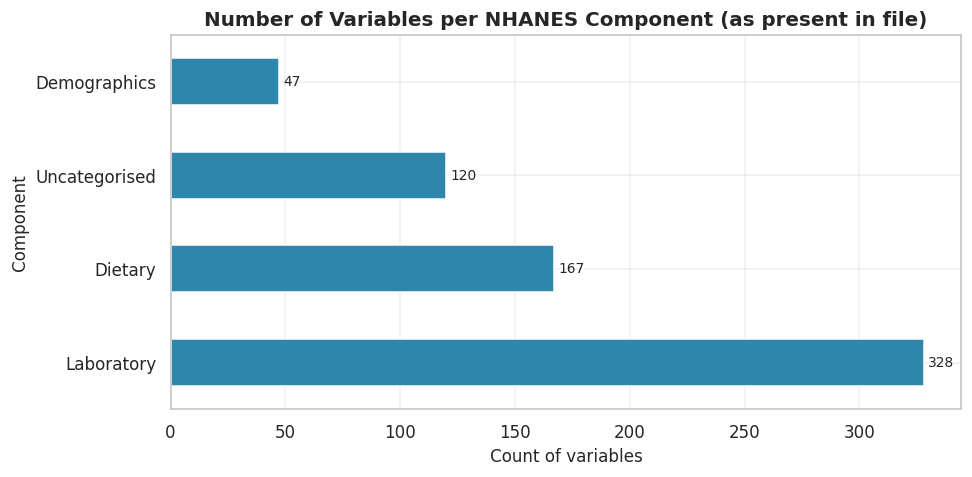

Laboratory       328
Dietary          167
Uncategorised    120
Demographics      47


In [4]:
# ---- Component composition of the columns present in the file ----
# Attribute each column to its NHANES component using the dictionary.
comp_of_col = pd.Series({c: VAR_COMP.get(c, 'Uncategorised') for c in raw.columns})
comp_counts = comp_of_col.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_counts.plot(kind='barh', color=PALETTE[0], ax=ax)
ax.set_title('Number of Variables per NHANES Component (as present in file)')
ax.set_xlabel('Count of variables')
ax.set_ylabel('Component')
for i, v in enumerate(comp_counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(comp_counts.to_string())

In [5]:
# ---- Column-level summary table: dtype, #missing, %missing, #unique ----
summary = pd.DataFrame({
    'dtype'      : raw.dtypes.astype(str),
    'n_missing'  : raw.isna().sum(),
    'pct_missing': (raw.isna().mean() * 100).round(1),
    'n_unique'   : raw.nunique(),
})
summary['component'] = [VAR_COMP.get(c, 'Uncategorised') for c in summary.index]
print('First 15 columns (column summary):')
summary.head(15)

First 15 columns (column summary):


,dtype,n_missing,pct_missing,n_unique,component
SEQN,int64,0,0.0,9813,Demographics
SDDSRVYR,int64,0,0.0,1,Demographics
RIDSTATR,int64,0,0.0,1,Demographics
RIAGENDR,int64,0,0.0,2,Demographics
RIDAGEYR,int64,0,0.0,81,Demographics
RIDAGEMN,float64,9171,93.5,25,Demographics
RIDRETH1,int64,0,0.0,5,Demographics
RIDRETH3,int64,0,0.0,6,Demographics
RIDEXMON,int64,0,0.0,2,Demographics
RIDEXAGM,float64,5600,57.1,240,Demographics


In [6]:
# ---- Statistical summary of a clinically important numeric subset ----
# (Describing all 662 columns is unreadable; we spotlight key clinical markers.)
KEY_PREVIEW = ['RIDAGEYR', 'DR1TKCAL', 'DR1TSUGR', 'DR1TSODI',
               'LBXGH', 'LBXSGL', 'LBXTC', 'LBDHDD', 'LBXSUA']
KEY_PREVIEW = [c for c in KEY_PREVIEW if c in raw.columns]
raw[KEY_PREVIEW].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,9813.0,31.63,24.40,0.00,10.00,27.00,52.00,80.0
DR1TKCAL,8531.0,1964.54,984.49,117.00,1309.50,1794.00,2430.00,12108.0
DR1TSUGR,8531.0,109.30,73.34,0.13,61.18,93.98,138.72,1115.5
DR1TSODI,8531.0,3178.13,1818.14,17.00,1975.00,2852.00,4028.50,21399.0
LBXGH,6643.0,5.64,1.00,3.50,5.20,5.40,5.80,17.5
LBXSGL,6553.0,102.29,38.72,49.00,86.00,93.00,104.00,577.0
LBXTC,7624.0,179.53,40.95,69.00,151.00,175.00,204.00,813.0
LBDHDD,7624.0,53.11,15.23,10.00,42.00,51.00,61.00,173.0
LBXSUA,6551.0,5.35,1.40,0.70,4.30,5.20,6.20,13.3


In [7]:
# ---- Duplicate records & unique-patient check ----
dup_full = raw.duplicated().sum()                       # fully identical rows
dup_id   = raw['SEQN'].duplicated().sum()               # repeated patient IDs
print(f'Fully duplicated rows        : {dup_full}')
print(f'Duplicated patient IDs (SEQN): {dup_id}')
print(f'Unique patients (SEQN)       : {raw["SEQN"].nunique():,}')

Fully duplicated rows        : 0
Duplicated patient IDs (SEQN): 0
Unique patients (SEQN)       : 9,813


In [8]:
# ---- Overall missing-value landscape ----
miss_pct = raw.isna().mean() * 100
print(f'Columns with ANY missing values : {(miss_pct > 0).sum():,} of {n_cols:,}')
print(f'Columns >50% missing            : {(miss_pct > 50).sum():,}')
print(f'Columns >90% missing            : {(miss_pct > 90).sum():,}')
print(f'Columns with NO missing values  : {(miss_pct == 0).sum():,}')
print(f'\nAverage missingness across all columns: {miss_pct.mean():.1f}%')

Columns with ANY missing values : 613 of 662
Columns >50% missing            : 334
Columns >90% missing            : 57
Columns with NO missing values  : 49

Average missingness across all columns: 51.2%


# 3 · Data Quality Analysis

**What we are doing:** a systematic audit of data quality *before* modelling.

**Why it is required:** Clustering is **distance-based and unsupervised**, so it has no label to "correct" it — it will faithfully cluster whatever structure exists, *including artefacts*. Garbage columns (constant, near-constant, or 90%-missing) distort distances and silhouette scores. This section quantifies six quality dimensions and visualises each:

1. **Missing values** — where and how much data is absent.
2. **Duplicates** — repeated records that would bias density.
3. **Unique values / constants** — columns carrying zero information.
4. **High-cardinality columns** — IDs/weights that must not be clustered on.
5. **Low-variance features** — features that barely move.
6. **Outliers & distributions** — skew and extremes that dominate Euclidean distance.

**Expected outcome:** a clear, evidence-based short-list of columns to drop and transformations to apply.

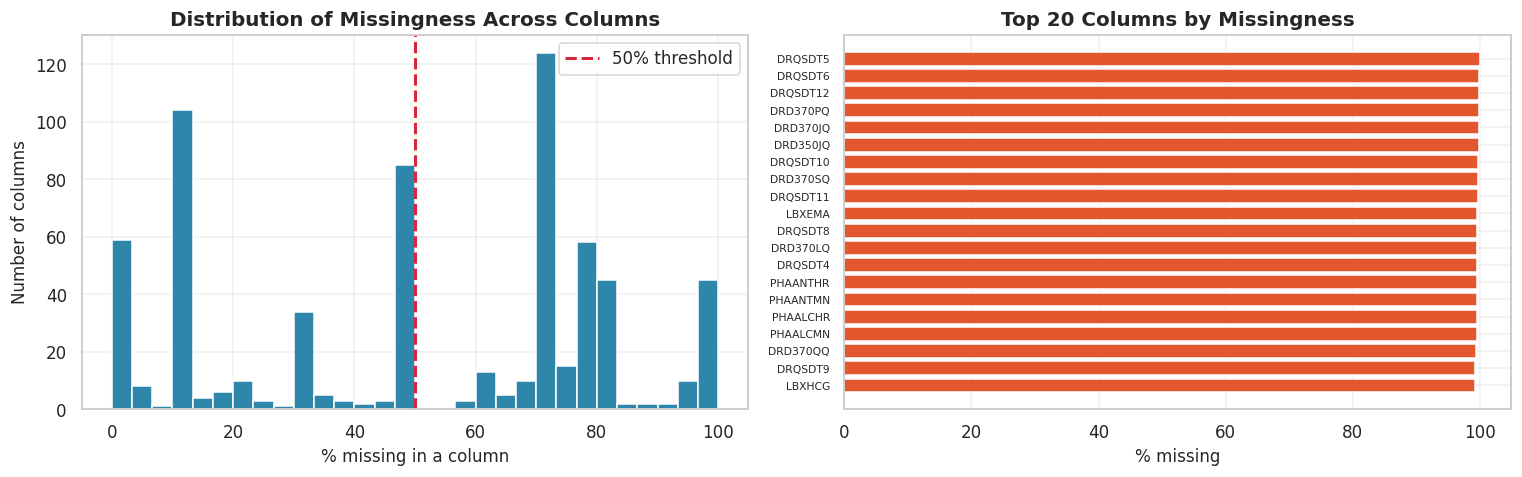

In [9]:
# ---- 3.1 Missing-value distribution across ALL columns ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Histogram of per-column missingness
axes[0].hist(miss_pct.values, bins=30, color=PALETTE[0], edgecolor='white')
axes[0].axvline(50, color=PALETTE[6], ls='--', lw=2, label='50% threshold')
axes[0].set_title('Distribution of Missingness Across Columns')
axes[0].set_xlabel('% missing in a column')
axes[0].set_ylabel('Number of columns')
axes[0].legend()

# (b) Top-20 most-missing columns
top_miss = miss_pct.sort_values(ascending=False).head(20)
axes[1].barh(top_miss.index[::-1], top_miss.values[::-1], color=PALETTE[1])
axes[1].set_title('Top 20 Columns by Missingness')
axes[1].set_xlabel('% missing')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

In [10]:
# ---- 3.2 Constant & quasi-constant columns (zero / near-zero information) ----
# A constant column has exactly 1 unique value; quasi-constant ~ 1 value >99% of the time.
nunq = raw.nunique(dropna=True)
constant_cols = nunq[nunq <= 1].index.tolist()

quasi_constant = []
for c in raw.columns:
    vc = raw[c].value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] > 0.99:      # dominant value in >99% of non-null rows
        quasi_constant.append(c)

print(f'Constant columns (<=1 unique value) : {len(constant_cols)}')
print(f'Quasi-constant columns (>99% one val): {len(quasi_constant)}')
print('\nExamples of quasi-constant columns:', quasi_constant[:10])

Constant columns (<=1 unique value) : 23
Quasi-constant columns (>99% one val): 63

Examples of quasi-constant columns: ['SDDSRVYR', 'RIDSTATR', 'FIAPROXY', 'MIAPROXY', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT6', 'DRQSDT7']


In [11]:
# ---- 3.3 High-cardinality columns (likely IDs, weights, continuous keys) ----
high_card = nunq[nunq > 0.9 * n_rows].index.tolist()
print(f'High-cardinality columns (>90% unique): {high_card}')
print('\nThese are identifiers / survey weights and MUST be excluded from clustering,')
print('because a near-unique value acts like a row index and carries no group structure.')

High-cardinality columns (>90% unique): ['SEQN', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25']

These are identifiers / survey weights and MUST be excluded from clustering,
because a near-unique value acts like a row index and carries no group structure.


In [12]:
# ---- 3.4 Outlier snapshot on key clinical markers (IQR method) ----
def iqr_outlier_pct(series):
    # % of observations beyond 1.5*IQR fences (Tukey's rule).
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

out_tbl = pd.DataFrame({
    'variable'   : KEY_PREVIEW,
    'description': [describe_var(c) for c in KEY_PREVIEW],
    'outlier_%'  : [round(iqr_outlier_pct(raw[c]), 1) for c in KEY_PREVIEW],
    'skew'       : [round(raw[c].skew(), 2) for c in KEY_PREVIEW],
})
out_tbl.sort_values('outlier_%', ascending=False)

,variable,description,outlier_%,skew
5,LBXSGL,"Glucose, refrigerated serum (mg/dL)",9.0,5.08
4,LBXGH,Glycohemoglobin (%),8.0,3.94
2,DR1TSUGR,Total sugars (gm),4.1,2.44
3,DR1TSODI,Sodium (mg),3.5,1.65
1,DR1TKCAL,Energy (kcal),3.2,1.71
7,LBDHDD,Direct HDL-Cholesterol (mg/dL),2.2,1.09
6,LBXTC,Total Cholesterol( mg/dL),1.2,1.33
8,LBXSUA,Uric acid (mg/dL),1.2,0.50
0,RIDAGEYR,Age in years of the participant at the time of...,0.0,0.43


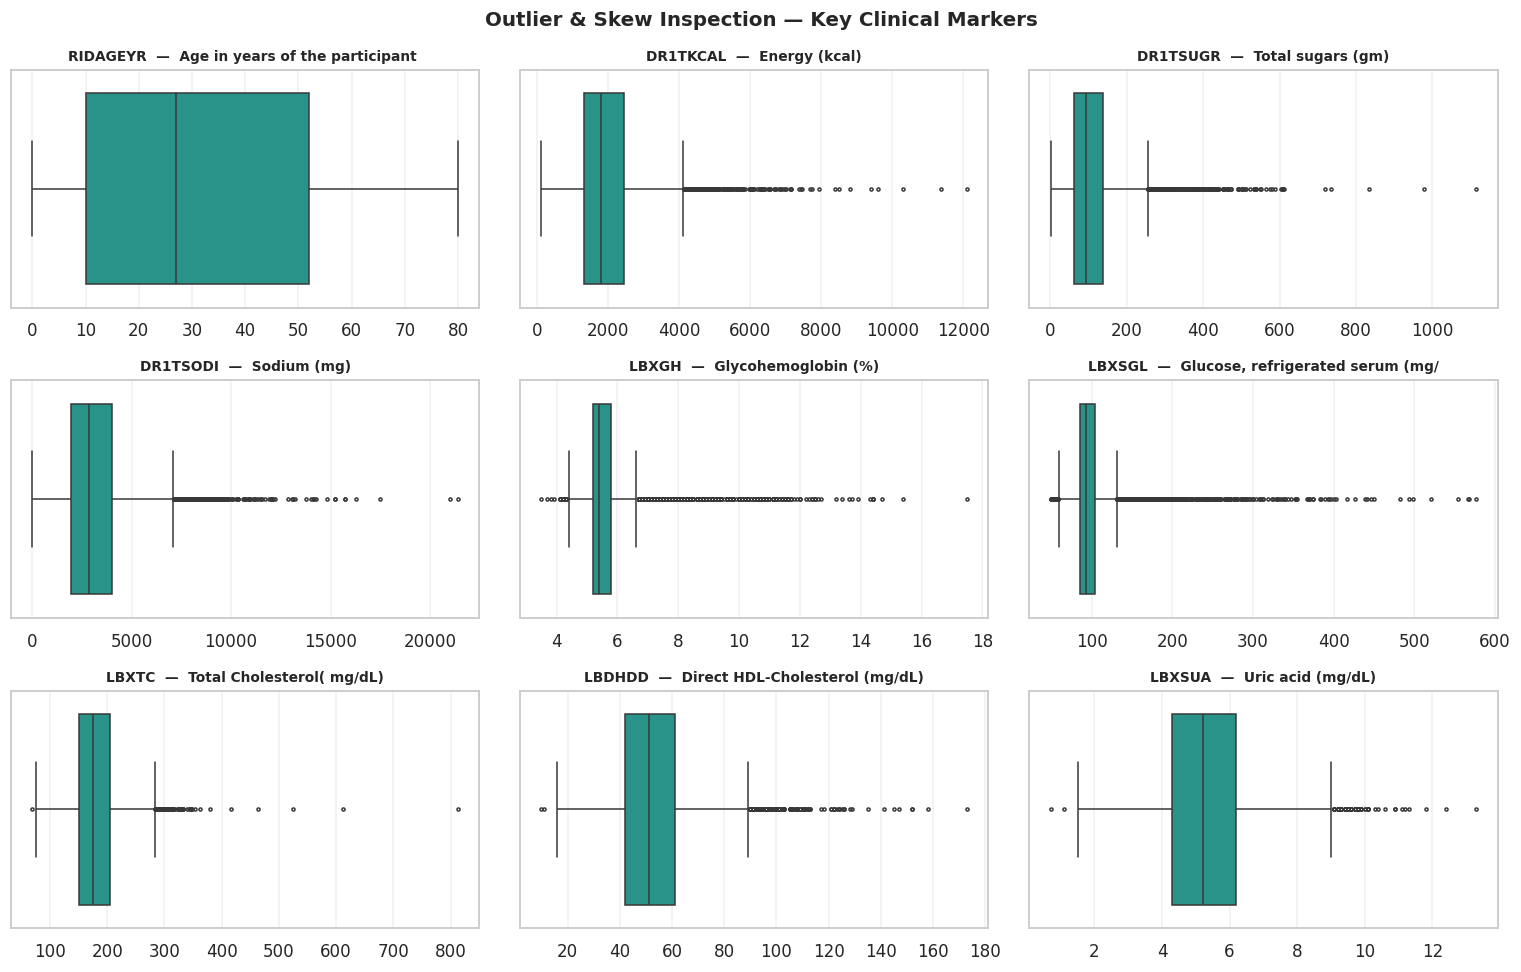

In [13]:
# ---- 3.5 Boxplots exposing outliers & skew in key clinical markers ----
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.ravel(), KEY_PREVIEW):
    sns.boxplot(x=raw[col], ax=ax, color=PALETTE[2], fliersize=2)
    ax.set_title(f'{col}  —  {describe_var(col)[:32]}', fontsize=9)
    ax.set_xlabel('')
# hide any unused axes
for ax in axes.ravel()[len(KEY_PREVIEW):]:
    ax.axis('off')
fig.suptitle('Outlier & Skew Inspection — Key Clinical Markers', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.6 Data-Quality Findings

- **Missingness is structural, not random.** NHANES collects different assays on different sub-samples (e.g. fasting-only tests such as LDL, triglycerides, and insulin sit near **68% missing** by design). These will be excluded from the core clustering feature set.
- **Many `LB…` laboratory columns are 90–100% missing** (rare-disease serology, environmental toxicants) — dropped as uninformative for general segmentation.
- **Identifier & survey-weight columns** (`SEQN`, `WT…`, `SDMVPSU`, …) are high-cardinality and must never enter a distance calculation.
- **Right-skew and heavy outliers** dominate dietary and lab markers (e.g. sodium, triglycerides) — motivating **robust handling and scaling** (Sections 5 & 9).

These findings drive every decision in the next section.

In [14]:
# ---- Overall missing-value landscape ----
miss_pct = raw.isna().mean() * 100
print(f'Columns with ANY missing values : {(miss_pct > 0).sum():,} of {n_cols:,}')
print(f'Columns >50% missing            : {(miss_pct > 50).sum():,}')
print(f'Columns >90% missing            : {(miss_pct > 90).sum():,}')
print(f'Columns with NO missing values  : {(miss_pct == 0).sum():,}')
print(f'\nAverage missingness across all columns: {miss_pct.mean():.1f}%')

Columns with ANY missing values : 613 of 662
Columns >50% missing            : 334
Columns >90% missing            : 57
Columns with NO missing values  : 49

Average missingness across all columns: 51.2%


# 4 · Data Cleaning & Feature Curation

**What we are doing:** transforming the raw 662-column survey dump into a clean, clinically coherent **analysis matrix**.

**Why it is required:** Clustering quality is bounded by input quality. Rather than blindly feeding 662 columns (most missing/irrelevant) into K-Means, we **curate a domain-driven feature set** grounded in cardiometabolic medicine, then clean it. Every decision below is justified.

### Cleaning decisions (and their rationale)

| Decision | Rationale |
|---|---|
| **Restrict to adults (age ≥ 18)** | Lab reference ranges, diet needs, and disease risk differ fundamentally for children; mixing them creates artificial age-driven clusters. |
| **Curate ~22 clinical features** | Demographic + dietary + laboratory markers with acceptable coverage and clear clinical meaning (metabolic & cardiovascular axes). |
| **Drop fasting-subsample labs** (LDL, triglycerides, insulin) | ~68% missing — imputing them would fabricate the majority of values. |
| **Drop rows missing >40% of curated features** | Too little signal to place reliably in feature space. |
| **Median-impute the remainder** | Median is robust to the heavy right-skew documented in §3. |
| **Remove one of each highly-correlated pair (\|r\|>0.95)** | Redundant features double-count a dimension and distort Euclidean distance. |
| **Coerce dtypes** | Guarantee every clustering feature is numeric. |

**Expected outcome:** a fully numeric, imputed, de-correlated `df_clean` matrix of adult patients, ready for feature engineering.

In [15]:
# ---- 4.1 Define the curated, clinically meaningful feature set ----
# Keys = NHANES codes; values = human-readable names used throughout the notebook.
FEATURES = {
    # ---------------- Demographic ----------------
    'RIDAGEYR': 'Age',
    'INDFMPIR': 'IncomeToPovertyRatio',
    # ---------------- Dietary (24-hr recall, Day 1) ----------------
    'DR1TKCAL': 'Energy_kcal',
    'DR1TPROT': 'Protein_g',
    'DR1TCARB': 'Carbohydrate_g',
    'DR1TSUGR': 'Sugar_g',
    'DR1TFIBE': 'Fiber_g',
    'DR1TTFAT': 'TotalFat_g',
    'DR1TSFAT': 'SaturatedFat_g',
    'DR1TSODI': 'Sodium_mg',
    # ---------------- Laboratory: metabolic ----------------
    'LBXGH'   : 'HbA1c_pct',        # glycohemoglobin — diabetes marker
    'LBXSGL'  : 'Glucose_mgdl',     # serum glucose
    'LBXTC'   : 'TotalChol_mgdl',   # total cholesterol
    'LBDHDD'  : 'HDL_mgdl',         # "good" cholesterol
    'LBXSUA'  : 'UricAcid_mgdl',    # gout / metabolic marker
    # ---------------- Laboratory: renal / hepatic ----------------
    'LBXSCR'  : 'Creatinine_mgdl',
    'LBXSBU'  : 'BUN_mgdl',
    'LBXSAL'  : 'Albumin_gdl',
    # ---------------- Laboratory: complete blood count ----------------
    'LBXWBCSI': 'WBC_1000cells',
    'LBXHGB'  : 'Hemoglobin_gdl',
    'LBXPLTSI': 'Platelets_1000',
}
# Categorical descriptors kept aside for PROFILING (not core clustering features).
CATEG = {'RIAGENDR': 'Gender', 'RIDRETH1': 'Race', 'DMDEDUC2': 'Education'}

present_feats = [c for c in FEATURES if c in raw.columns]
print(f'Curated numeric features present: {len(present_feats)} / {len(FEATURES)}')
print(f'Categorical descriptors present : {len([c for c in CATEG if c in raw.columns])}')

Curated numeric features present: 21 / 21
Categorical descriptors present : 3


In [16]:
# ---- 4.2 Restrict to the adult cohort (age >= 18) ----
work = raw[raw['RIDAGEYR'] >= 18].copy()
print(f'Adults (age >= 18): {work.shape[0]:,}  (removed {raw.shape[0]-work.shape[0]:,} minors)')

# ---- 4.3 Assemble the working frame: curated features + descriptors + ID ----
keep_cols = ['SEQN'] + present_feats + [c for c in CATEG if c in work.columns]
work = work[keep_cols].copy()

# Rename NHANES codes -> readable names for the numeric features
work = work.rename(columns={**FEATURES, **CATEG})
FEAT_NAMES = [FEATURES[c] for c in present_feats]     # readable clustering-feature names
print(f'Working frame: {work.shape[0]:,} rows x {work.shape[1]} columns')

Adults (age >= 18): 5,924  (removed 3,889 minors)
Working frame: 5,924 rows x 25 columns


In [17]:
# ---- 4.4 Drop rows with excessive missingness (>40% of curated features) ----
thresh = int(0.60 * len(FEAT_NAMES))                  # require >=60% of features present
before = work.shape[0]
work = work.dropna(subset=FEAT_NAMES, thresh=thresh).reset_index(drop=True)
print(f'Rows kept after >=60%-complete filter: {work.shape[0]:,} (removed {before-work.shape[0]:,})')

# ---- 4.5 Median-impute remaining missing values in numeric features ----
imputer = SimpleImputer(strategy='median')
work[FEAT_NAMES] = imputer.fit_transform(work[FEAT_NAMES])
print('Remaining missing values in features after imputation:',
      int(work[FEAT_NAMES].isna().sum().sum()))

Rows kept after >=60%-complete filter: 5,686 (removed 238)
Remaining missing values in features after imputation: 0


In [18]:
# ---- 4.6 Remove highly-correlated redundant features (|r| > 0.95) ----
corr = work[FEAT_NAMES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > 0.95).any()]
print('Highly-correlated features removed (|r|>0.95):', to_drop if to_drop else 'None')

FEAT_NAMES = [f for f in FEAT_NAMES if f not in to_drop]
df_clean = work.copy()
print(f'\nFinal clustering feature count: {len(FEAT_NAMES)}')
print(f'Clean adult analysis matrix   : {df_clean.shape[0]:,} patients x {len(FEAT_NAMES)} features')

Highly-correlated features removed (|r|>0.95): None

Final clustering feature count: 21
Clean adult analysis matrix   : 5,686 patients x 21 features


# 5 · Exploratory Data Analysis (EDA)

**What we are doing:** exploring the cleaned adult cohort through **25+ visualisations** — univariate distributions, bivariate relationships, and multivariate structure.

**Why it is required:** EDA is how we *earn intuition* about the data before letting an algorithm impose structure. It reveals the **shape** (skew, modality), **scale** (why scaling is mandatory), and **correlations** (why PCA will help) that determine which clustering choices are sound. In healthcare it also validates that the numbers are *clinically plausible* (e.g. HbA1c mostly in the 4–14% range).

**Expected outcome:** a visual, clinically-annotated understanding of every feature and the relationships the clustering will later exploit.

*(We first decode the categorical NHANES codes into human-readable labels for interpretable plots.)*

In [19]:
# ---- 5.0 Decode categorical NHANES codes into readable labels (for plots) ----
GENDER_MAP = {1: 'Male', 2: 'Female'}
RACE_MAP = {1: 'Mexican American', 2: 'Other Hispanic', 3: 'Non-Hisp. White',
            4: 'Non-Hisp. Black', 5: 'Other/Multi'}
EDU_MAP = {1: '<9th grade', 2: '9-11th grade', 3: 'HS grad/GED',
           4: 'Some college', 5: 'College grad+', 7: np.nan, 9: np.nan}

df_eda = df_clean.copy()
if 'Gender' in df_eda:    df_eda['Gender_lbl'] = df_eda['Gender'].map(GENDER_MAP)
if 'Race' in df_eda:      df_eda['Race_lbl']   = df_eda['Race'].map(RACE_MAP)
if 'Education' in df_eda: df_eda['Edu_lbl']    = df_eda['Education'].map(EDU_MAP)

# Derived age-group column purely for EDA readability
df_eda['AgeGroup'] = pd.cut(df_eda['Age'], bins=[17, 30, 45, 60, 75, 120],
                            labels=['18-30', '31-45', '46-60', '61-75', '75+'])
print('Categorical labels decoded for EDA.')

Categorical labels decoded for EDA.


## 5.1 Demographic Distributions
Figures 1–4 describe *who* is in the cohort — the population on which every downstream segment is built.

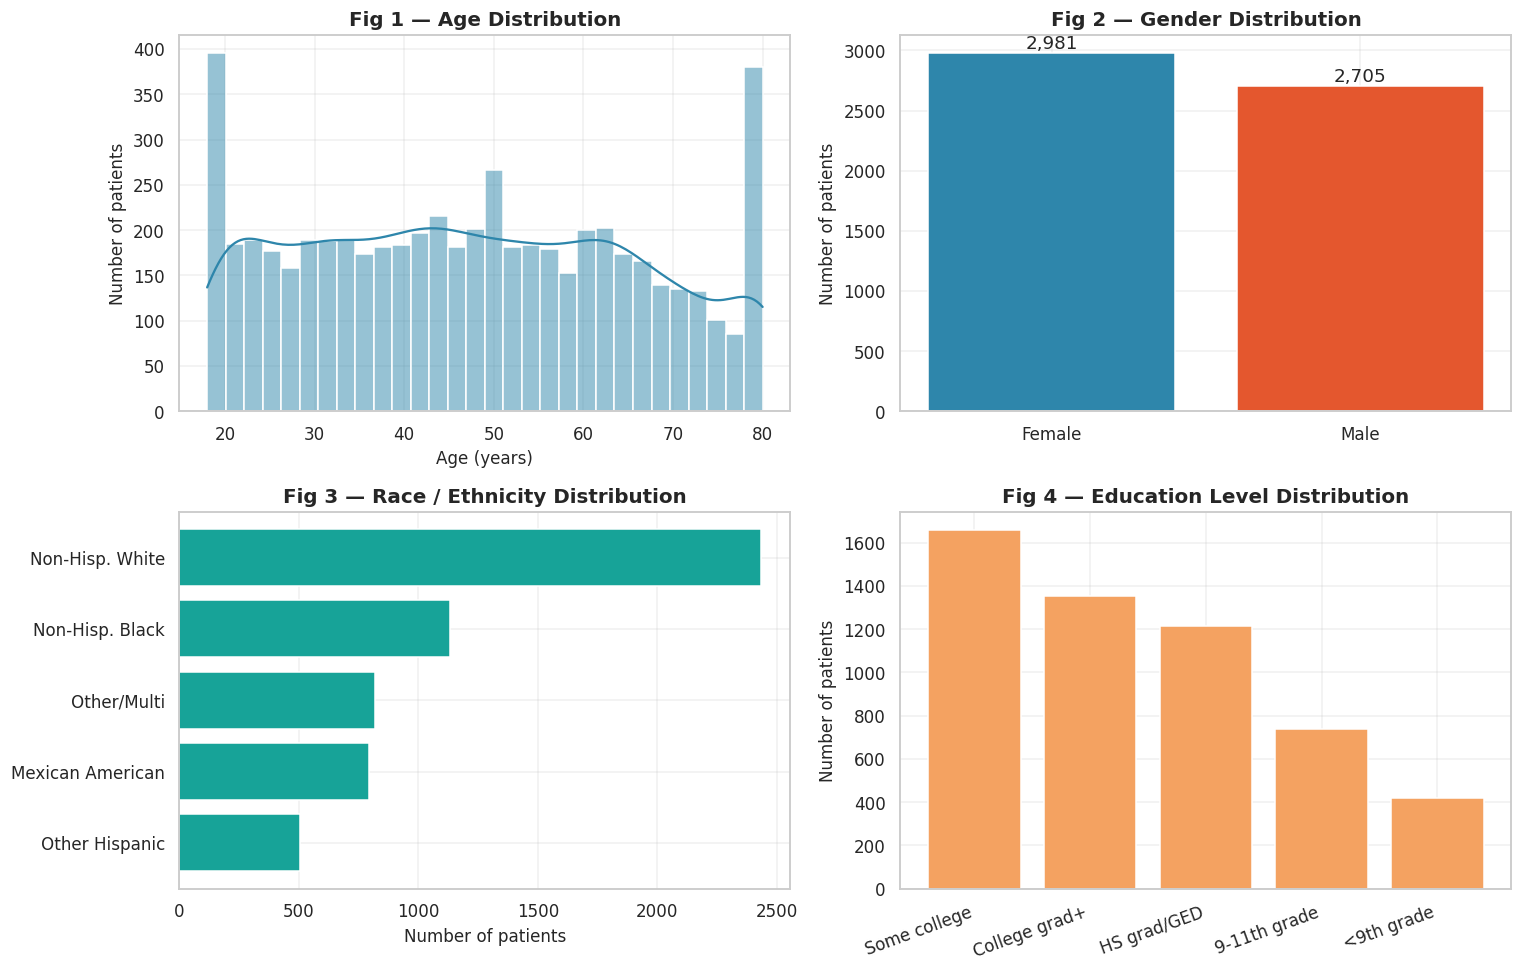

In [20]:
# ===== Figures 1-4: Age, Gender, Race, Education =====
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Fig 1 — Age distribution (histogram + KDE)
sns.histplot(df_eda['Age'], bins=30, kde=True, color=PALETTE[0], ax=axes[0, 0])
axes[0, 0].set_title('Fig 1 — Age Distribution')
axes[0, 0].set_xlabel('Age (years)'); axes[0, 0].set_ylabel('Number of patients')

# Fig 2 — Gender distribution
gc = df_eda['Gender_lbl'].value_counts()
axes[0, 1].bar(gc.index, gc.values, color=[PALETTE[0], PALETTE[1]])
axes[0, 1].set_title('Fig 2 — Gender Distribution')
axes[0, 1].set_ylabel('Number of patients')
for i, v in enumerate(gc.values): axes[0, 1].text(i, v, f'{v:,}', ha='center', va='bottom')

# Fig 3 — Race / ethnicity distribution
rc = df_eda['Race_lbl'].value_counts()
axes[1, 0].barh(rc.index[::-1], rc.values[::-1], color=PALETTE[2])
axes[1, 0].set_title('Fig 3 — Race / Ethnicity Distribution')
axes[1, 0].set_xlabel('Number of patients')

# Fig 4 — Education distribution
ec = df_eda['Edu_lbl'].value_counts()
axes[1, 1].bar(range(len(ec)), ec.values, color=PALETTE[3])
axes[1, 1].set_xticks(range(len(ec))); axes[1, 1].set_xticklabels(ec.index, rotation=20, ha='right')
axes[1, 1].set_title('Fig 4 — Education Level Distribution')
axes[1, 1].set_ylabel('Number of patients')

plt.tight_layout(); plt.show()

## 5.2 Metabolic & Cardiovascular Laboratory Markers
Figures 5–10 profile the clinical blood markers that anchor cardiometabolic risk — the core signal we expect the clustering to separate on. Clinical reference thresholds are annotated.

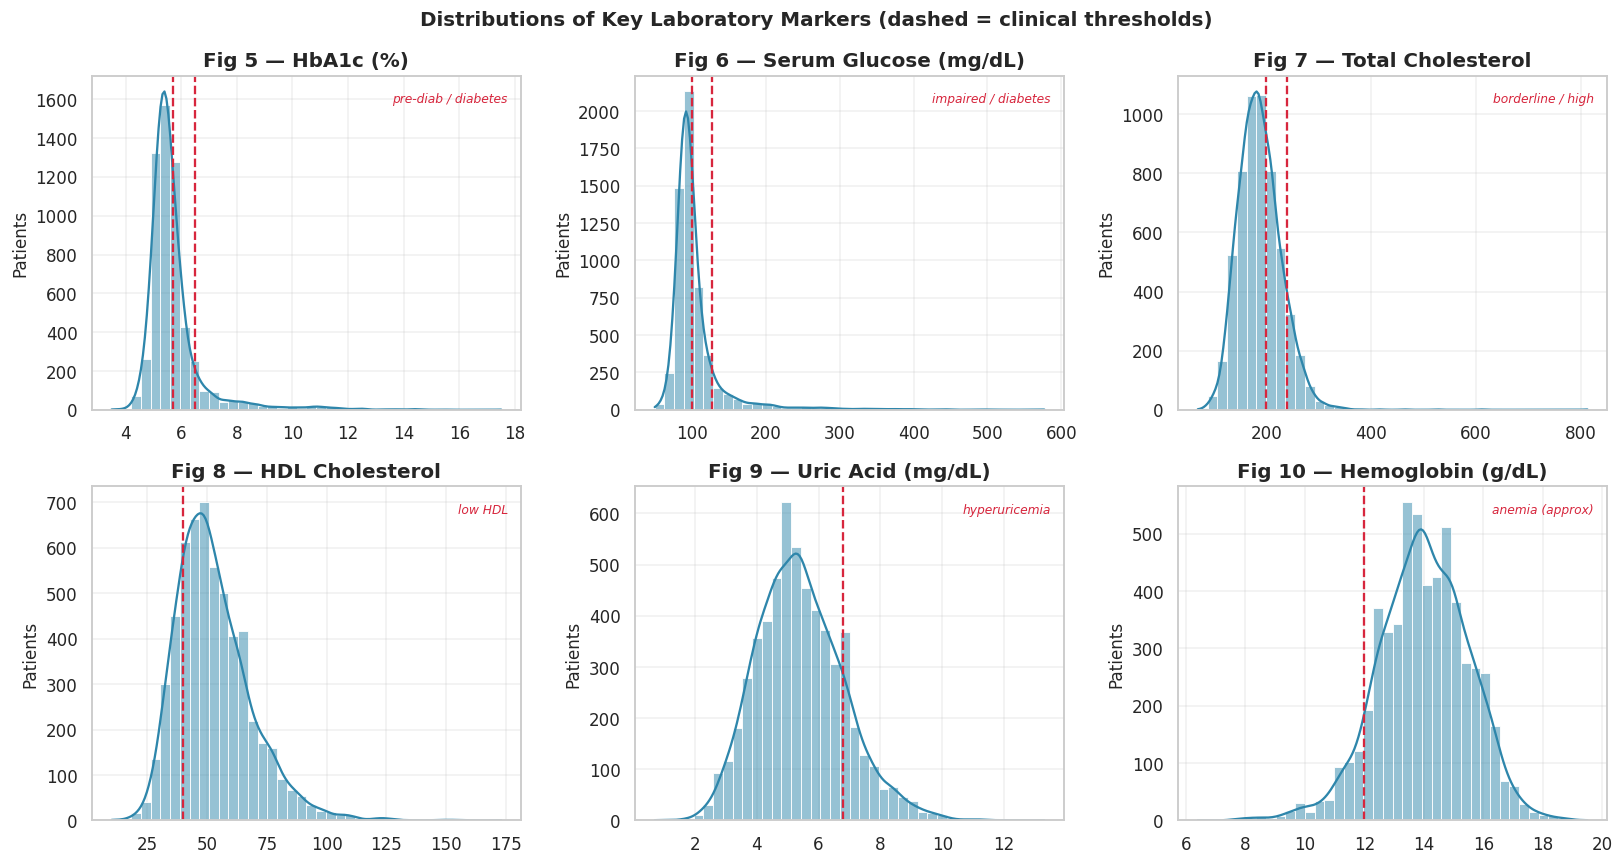

In [21]:
# ===== Figures 5-10: distributions of key lab markers with clinical thresholds =====
lab_specs = [
    ('HbA1c_pct',      'Fig 5 — HbA1c (%)',            [5.7, 6.5], 'pre-diab / diabetes'),
    ('Glucose_mgdl',   'Fig 6 — Serum Glucose (mg/dL)',[100, 126], 'impaired / diabetes'),
    ('TotalChol_mgdl', 'Fig 7 — Total Cholesterol',    [200, 240], 'borderline / high'),
    ('HDL_mgdl',       'Fig 8 — HDL Cholesterol',      [40],       'low HDL'),
    ('UricAcid_mgdl',  'Fig 9 — Uric Acid (mg/dL)',    [6.8],      'hyperuricemia'),
    ('Hemoglobin_gdl', 'Fig 10 — Hemoglobin (g/dL)',   [12],       'anemia (approx)'),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, title, thr, note) in zip(axes.ravel(), lab_specs):
    if col not in df_eda: ax.axis('off'); continue
    sns.histplot(df_eda[col], bins=40, kde=True, color=PALETTE[0], ax=ax)
    for t in thr:
        ax.axvline(t, color=PALETTE[6], ls='--', lw=1.5)
    ax.set_title(title); ax.set_xlabel(''); ax.set_ylabel('Patients')
    ax.text(0.97, 0.92, note, transform=ax.transAxes, ha='right',
            fontsize=8, color=PALETTE[6], style='italic')
fig.suptitle('Distributions of Key Laboratory Markers (dashed = clinical thresholds)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5.3 Dietary Intake Distributions
Figures 11–14 characterise nutrition — the modifiable, lifestyle side of risk that underpins dietary intervention recommendations.

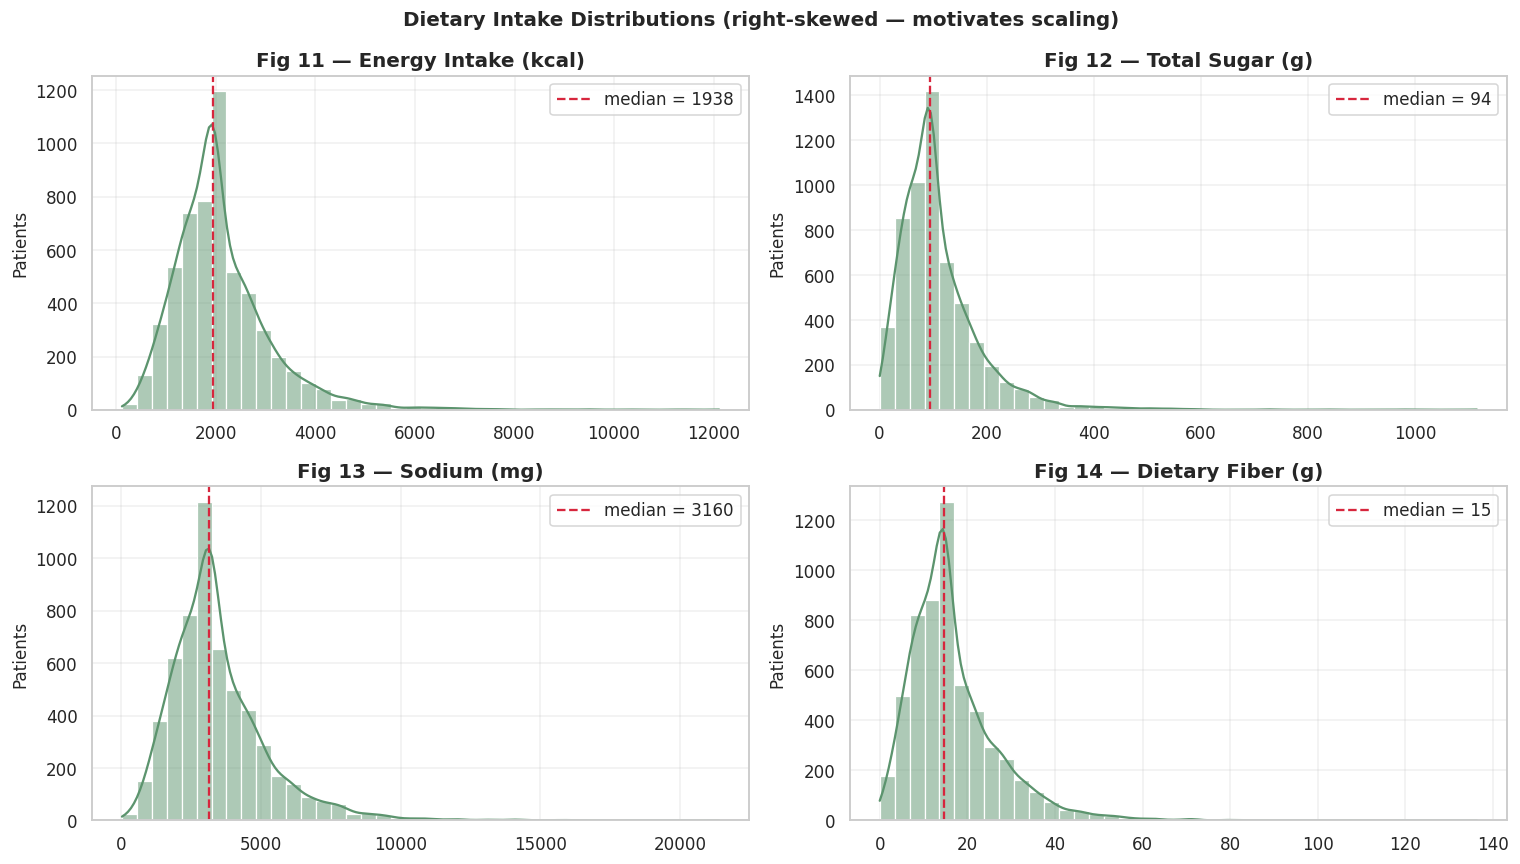

In [22]:
# ===== Figures 11-14: dietary intake distributions =====
diet_specs = [('Energy_kcal', 'Fig 11 — Energy Intake (kcal)'),
              ('Sugar_g',     'Fig 12 — Total Sugar (g)'),
              ('Sodium_mg',   'Fig 13 — Sodium (mg)'),
              ('Fiber_g',     'Fig 14 — Dietary Fiber (g)')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, title) in zip(axes.ravel(), diet_specs):
    if col not in df_eda: ax.axis('off'); continue
    sns.histplot(df_eda[col], bins=40, kde=True, color=PALETTE[5], ax=ax)
    ax.axvline(df_eda[col].median(), color=PALETTE[6], ls='--', lw=1.5,
               label=f'median = {df_eda[col].median():.0f}')
    ax.set_title(title); ax.set_xlabel(''); ax.set_ylabel('Patients'); ax.legend()
fig.suptitle('Dietary Intake Distributions (right-skewed — motivates scaling)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5.4 Group Comparisons — Boxplots & Violin Plots
Figures 15–18 compare marker levels **across demographic groups**, exposing the interactions (age×metabolism, gender×lipids) that clustering will later formalise.

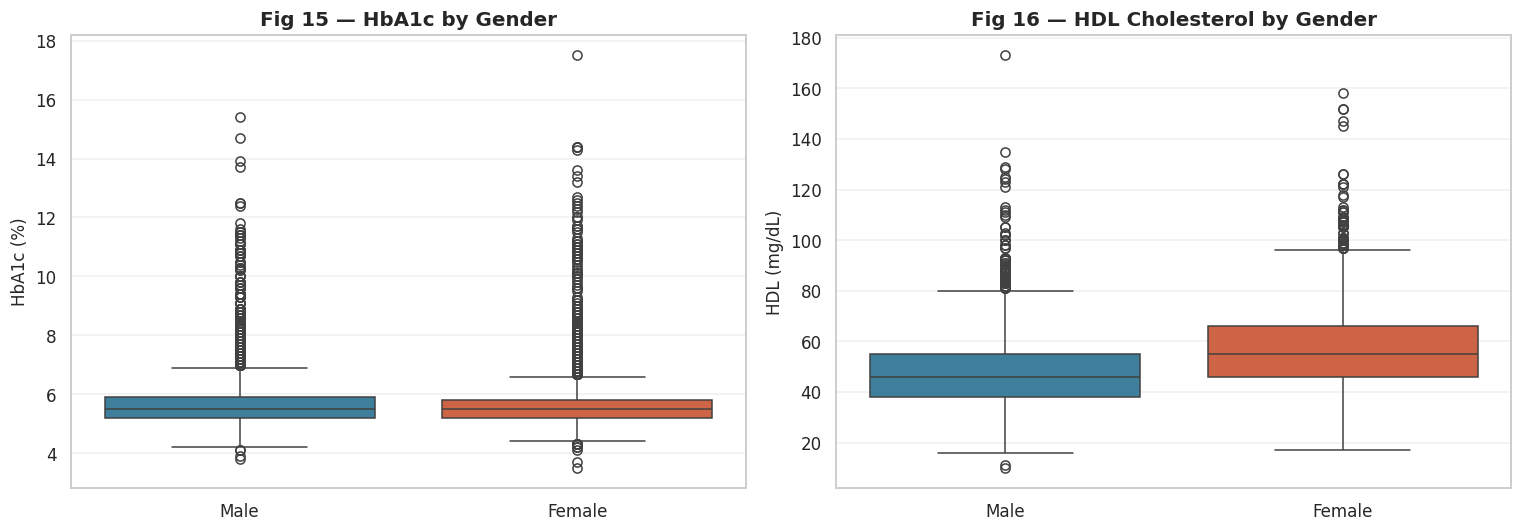

In [23]:
# ===== Figures 15-16: Boxplots of labs by Gender =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_eda, x='Gender_lbl', y='HbA1c_pct', ax=axes[0], palette=PALETTE[:2])
axes[0].set_title('Fig 15 — HbA1c by Gender'); axes[0].set_xlabel(''); axes[0].set_ylabel('HbA1c (%)')
sns.boxplot(data=df_eda, x='Gender_lbl', y='HDL_mgdl', ax=axes[1], palette=PALETTE[:2])
axes[1].set_title('Fig 16 — HDL Cholesterol by Gender'); axes[1].set_xlabel(''); axes[1].set_ylabel('HDL (mg/dL)')
plt.tight_layout(); plt.show()

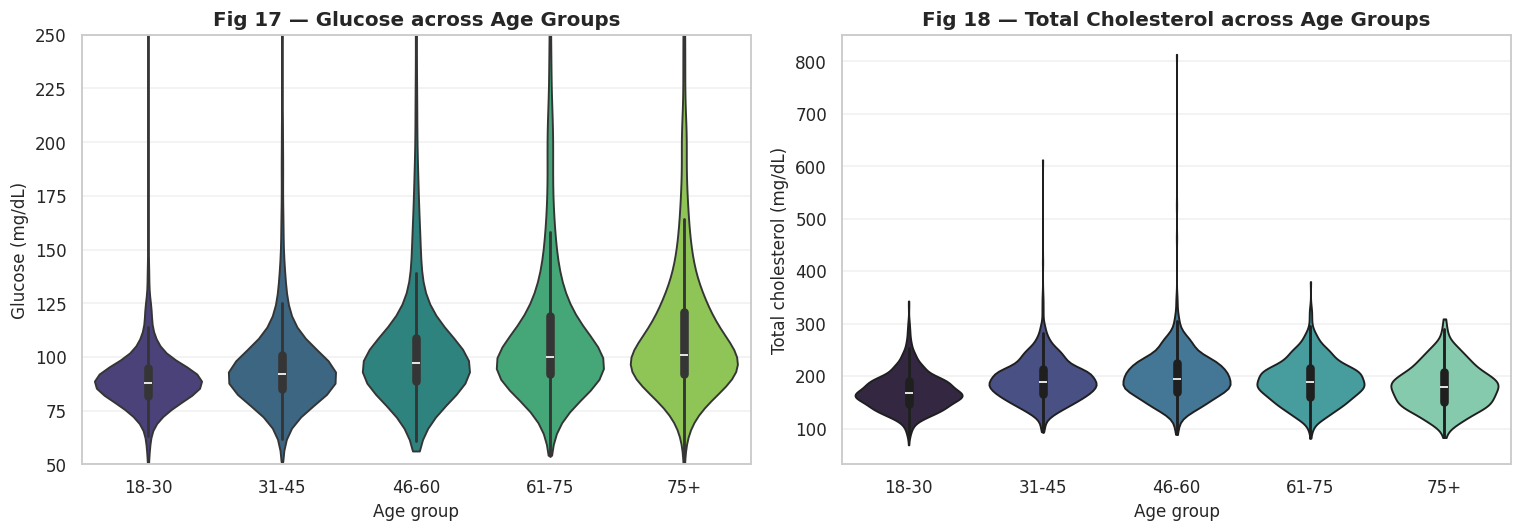

In [24]:
# ===== Figures 17-18: Violin plots across age groups =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df_eda, x='AgeGroup', y='Glucose_mgdl', ax=axes[0],
               palette='viridis', cut=0)
axes[0].set_title('Fig 17 — Glucose across Age Groups'); axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Glucose (mg/dL)'); axes[0].set_ylim(50, 250)
sns.violinplot(data=df_eda, x='AgeGroup', y='TotalChol_mgdl', ax=axes[1],
               palette='mako', cut=0)
axes[1].set_title('Fig 18 — Total Cholesterol across Age Groups'); axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Total cholesterol (mg/dL)')
plt.tight_layout(); plt.show()

## 5.5 Correlation Structure
Figure 19 is the **correlation heatmap** — arguably the single most important EDA artefact for this project. Blocks of correlated features signal **redundant dimensions**, which is exactly the motivation for **PCA** (Section 13).

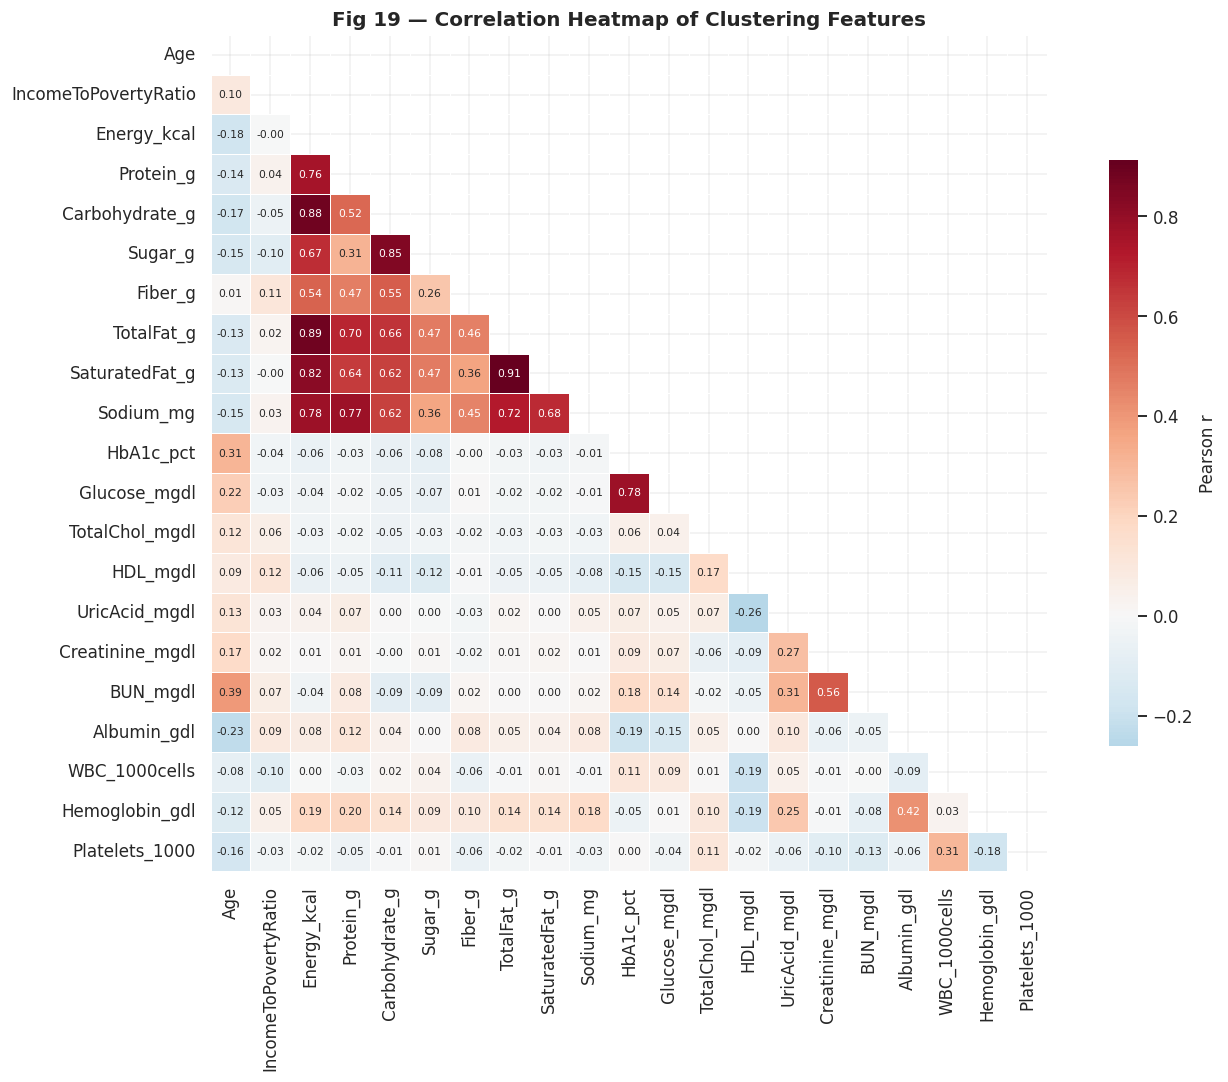

In [25]:
# ===== Figure 19: Correlation heatmap of all clustering features =====
plt.figure(figsize=(13, 10))
corr_mat = df_clean[FEAT_NAMES].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))     # show lower triangle only
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
plt.title('Fig 19 — Correlation Heatmap of Clustering Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5.6 Bivariate Relationships — Scatter Plots
Figures 20–22 examine clinically meaningful marker pairs. HbA1c-vs-Glucose should be *strongly positive* (both track glycaemia); this sanity-checks the data and previews a metabolic axis of separation.

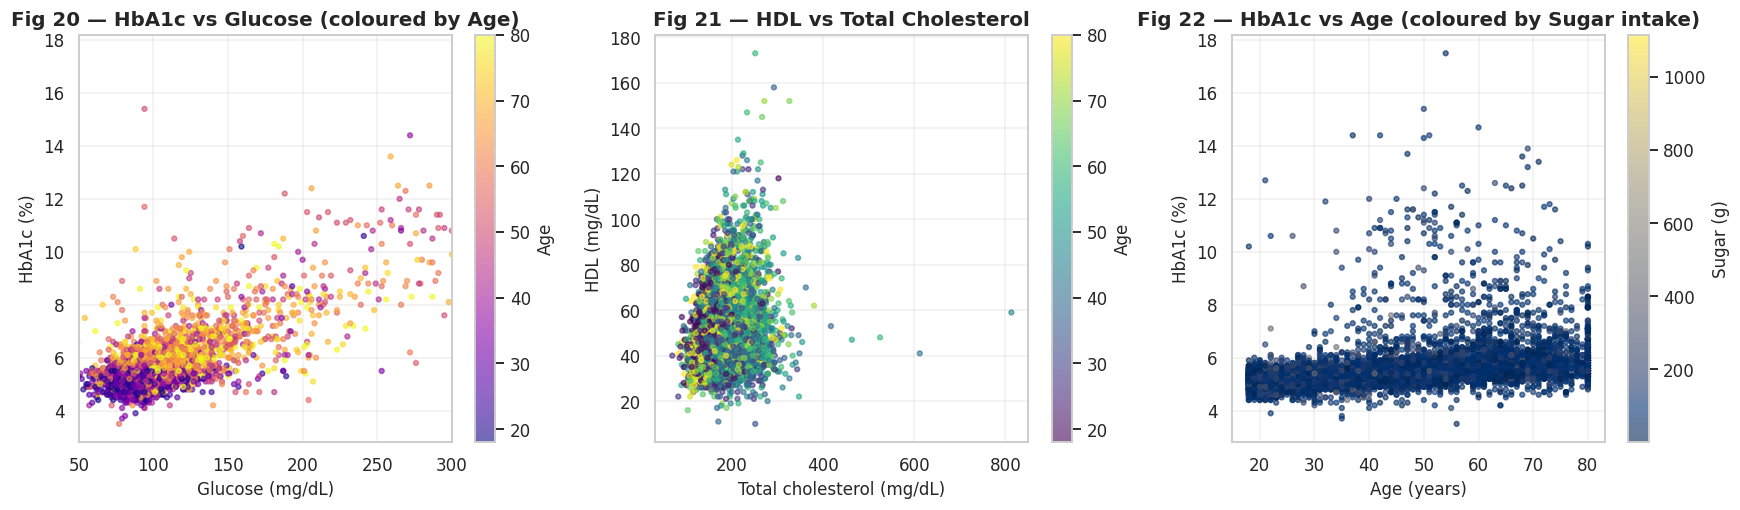

In [26]:
# ===== Figures 20-22: clinically meaningful scatter plots =====
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sc0 = axes[0].scatter(df_eda['Glucose_mgdl'], df_eda['HbA1c_pct'],
                      c=df_eda['Age'], cmap='plasma', s=10, alpha=0.6)
axes[0].set_title('Fig 20 — HbA1c vs Glucose (coloured by Age)')
axes[0].set_xlabel('Glucose (mg/dL)'); axes[0].set_ylabel('HbA1c (%)')
axes[0].set_xlim(50, 300); plt.colorbar(sc0, ax=axes[0], label='Age')

sc1 = axes[1].scatter(df_eda['TotalChol_mgdl'], df_eda['HDL_mgdl'],
                      c=df_eda['Age'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Fig 21 — HDL vs Total Cholesterol')
axes[1].set_xlabel('Total cholesterol (mg/dL)'); axes[1].set_ylabel('HDL (mg/dL)')
plt.colorbar(sc1, ax=axes[1], label='Age')

sc2 = axes[2].scatter(df_eda['Age'], df_eda['HbA1c_pct'],
                      c=df_eda['Sugar_g'], cmap='cividis', s=10, alpha=0.6)
axes[2].set_title('Fig 22 — HbA1c vs Age (coloured by Sugar intake)')
axes[2].set_xlabel('Age (years)'); axes[2].set_ylabel('HbA1c (%)')
plt.colorbar(sc2, ax=axes[2], label='Sugar (g)')
plt.tight_layout(); plt.show()

## 5.7 Multivariate View — Pair Plot & Density
Figures 23–25 give a joint multivariate view of the core metabolic markers, plus overlaid densities that make scale differences (and the need for scaling) unmistakable.

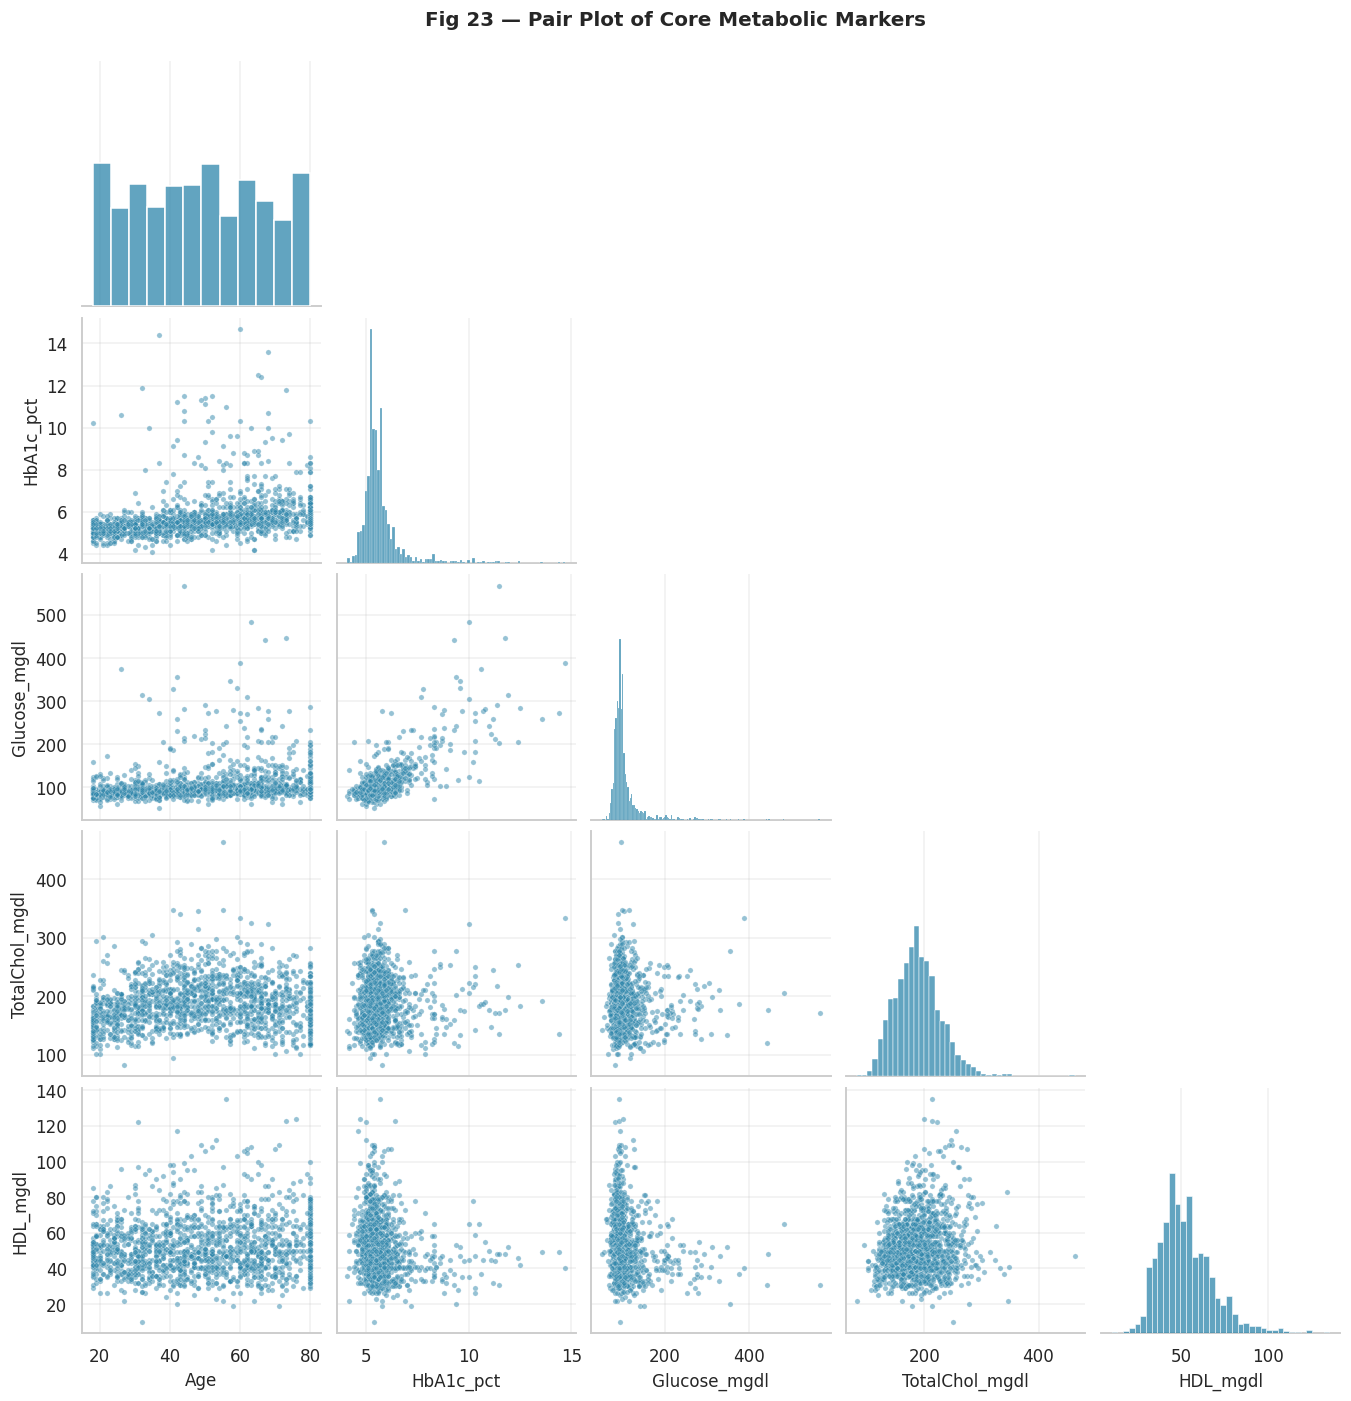

In [27]:
# ===== Figure 23: Pair plot of core metabolic markers =====
pair_feats = [f for f in ['Age', 'HbA1c_pct', 'Glucose_mgdl', 'TotalChol_mgdl', 'HDL_mgdl']
              if f in df_eda]
pp = sns.pairplot(df_eda[pair_feats].sample(min(1500, len(df_eda)), random_state=RANDOM_STATE),
                  corner=True, plot_kws={'s': 12, 'alpha': 0.5, 'color': PALETTE[0]},
                  diag_kws={'color': PALETTE[0]})
pp.fig.suptitle('Fig 23 — Pair Plot of Core Metabolic Markers', y=1.02,
                fontsize=13, fontweight='bold')
plt.show()

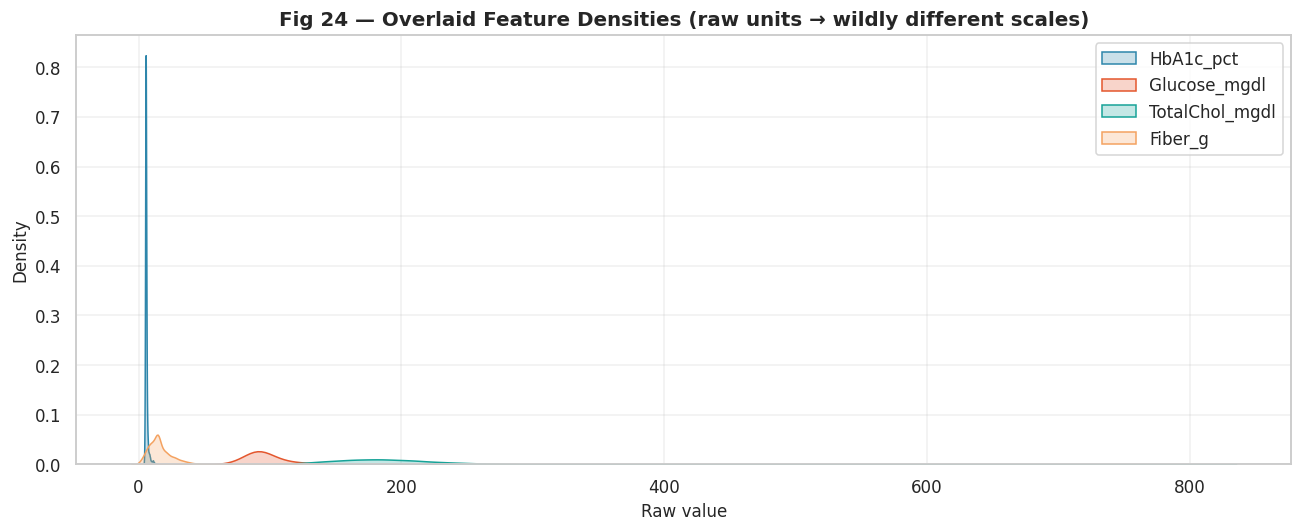

In [28]:
# ===== Figure 24: Overlaid KDE densities (standardised) to expose scale spread =====
plt.figure(figsize=(12, 5))
for f in ['HbA1c_pct', 'Glucose_mgdl', 'TotalChol_mgdl', 'Fiber_g']:
    if f in df_eda:
        sns.kdeplot(df_eda[f], label=f, fill=True, alpha=0.25)
plt.title('Fig 24 — Overlaid Feature Densities (raw units → wildly different scales)')
plt.xlabel('Raw value'); plt.ylabel('Density'); plt.legend()
plt.tight_layout(); plt.show()

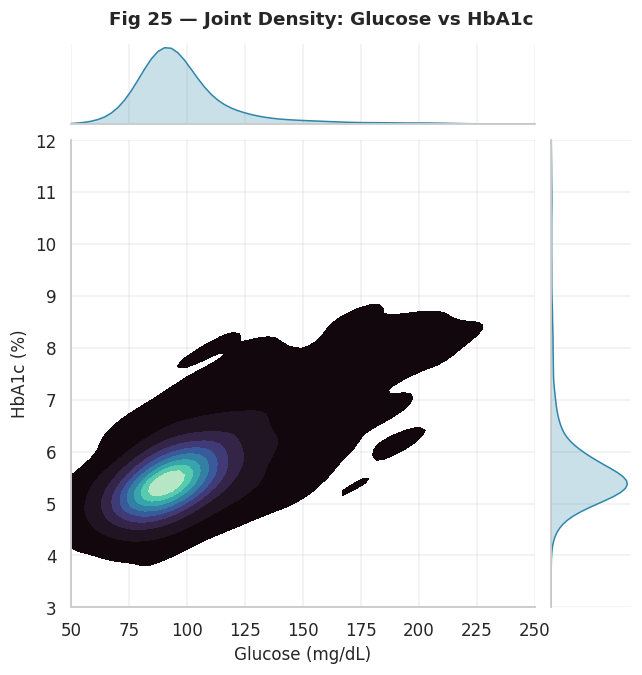

In [29]:
# ===== Figure 25: Joint KDE — Glucose vs HbA1c (metabolic core) =====
jp = sns.jointplot(data=df_eda, x='Glucose_mgdl', y='HbA1c_pct', kind='kde',
                   fill=True, cmap='mako', height=6, xlim=(50, 250), ylim=(3, 12))
jp.fig.suptitle('Fig 25 — Joint Density: Glucose vs HbA1c', y=1.02,
                fontsize=12, fontweight='bold')
jp.set_axis_labels('Glucose (mg/dL)', 'HbA1c (%)')
plt.show()

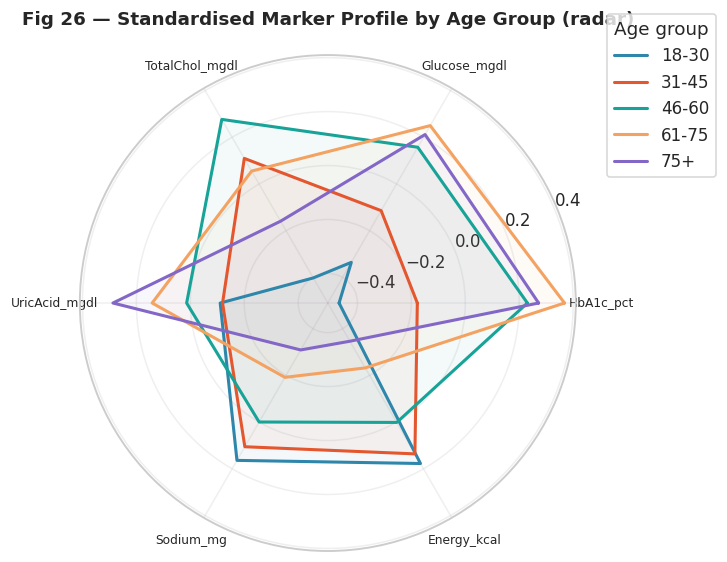

In [30]:
# ===== Figure 26 (bonus): Radar chart of mean standardised profile by age group =====
from math import pi
radar_feats = ['HbA1c_pct', 'Glucose_mgdl', 'TotalChol_mgdl', 'UricAcid_mgdl',
               'Sodium_mg', 'Energy_kcal']
radar_feats = [f for f in radar_feats if f in df_eda]
z = (df_eda[radar_feats] - df_eda[radar_feats].mean()) / df_eda[radar_feats].std()
z['AgeGroup'] = df_eda['AgeGroup']
means = z.groupby('AgeGroup')[radar_feats].mean()

angles = [n / len(radar_feats) * 2 * pi for n in range(len(radar_feats))] + [0]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (grp, row) in enumerate(means.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, label=str(grp), color=PALETTE[i % len(PALETTE)], lw=2)
    ax.fill(angles, vals, color=PALETTE[i % len(PALETTE)], alpha=0.05)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_feats, fontsize=8)
ax.set_title('Fig 26 — Standardised Marker Profile by Age Group (radar)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Age group')
plt.tight_layout(); plt.show()

### 5.8 EDA Takeaways
- **Scales differ by orders of magnitude** (Sodium in the thousands, HbA1c in single digits) → **feature scaling is mandatory** before any distance-based clustering (Section 9).
- **Right-skew and outliers** are pervasive in diet & lab markers → informs scaler choice and interpretation.
- **Correlated blocks** (glucose↔HbA1c; total-cholesterol↔LDL-like lipids; CBC markers) → **redundancy that PCA will compress** (Section 13).
- Clear **age- and gender-linked gradients** in metabolic markers → real, clinically sensible structure exists for clustering to recover.

# 6 · Feature Engineering

**What we are doing:** deriving new, clinically-motivated features from the raw markers.

**Why it is required:** Raw lab values are powerful, but clinicians reason in terms of *categories* and *ratios* (e.g. "pre-diabetic", "atherogenic index"). Engineered features (a) make clusters interpretable, (b) encode domain knowledge the algorithm would otherwise have to rediscover, and (c) create composite risk axes that sharpen separation.

**Mathematical intuition:** a ratio such as $\text{TC}/\text{HDL}$ is a *non-linear* combination that captures cardiovascular risk more compactly than either component alone; a *risk count* $\sum_j \mathbb{1}[\text{marker}_j \text{ abnormal}]$ turns many continuous markers into a single monotone severity axis.

**Healthcare relevance:** these are the exact constructs used in clinical guidelines (ADA HbA1c bands, ATP-III lipid ratios), so downstream cluster names will map directly onto medical language.

**Expected outcome:** a richer feature matrix plus interpretable categorical labels for profiling.

In [31]:
# ---- 6.1 Clinical CATEGORY features (for interpretation / profiling) ----
fe = df_clean.copy()

# HbA1c bands (American Diabetes Association)
fe['HbA1c_Category'] = pd.cut(fe['HbA1c_pct'], bins=[0, 5.7, 6.5, 100],
                              labels=['Normal', 'Prediabetes', 'Diabetes'])
# Fasting-ish glucose bands (approximate; NHANES glucose not strictly fasting for all)
fe['Glucose_Category'] = pd.cut(fe['Glucose_mgdl'], bins=[0, 100, 126, 1000],
                                labels=['Normal', 'Impaired', 'Diabetic-range'])
# Total cholesterol bands (ATP-III)
fe['Chol_Category'] = pd.cut(fe['TotalChol_mgdl'], bins=[0, 200, 240, 1000],
                             labels=['Desirable', 'Borderline', 'High'])
# Age band (ordinal)
fe['AgeGroup'] = pd.cut(fe['Age'], bins=[17, 30, 45, 60, 75, 120],
                        labels=['18-30', '31-45', '46-60', '61-75', '75+'])

print(fe['HbA1c_Category'].value_counts(dropna=False).to_string())

HbA1c_Category
Normal         3995
Prediabetes    1138
Diabetes        553


In [32]:
# ---- 6.2 Continuous ENGINEERED features (added to the clustering matrix) ----
# (a) Atherogenic index: Total Cholesterol / HDL  (higher = worse CV risk)
fe['CholHDL_Ratio'] = fe['TotalChol_mgdl'] / fe['HDL_mgdl'].replace(0, np.nan)
fe['CholHDL_Ratio'] = fe['CholHDL_Ratio'].fillna(fe['CholHDL_Ratio'].median())

# (b) Diet Quality Score: reward fibre, penalise sugar/sodium/saturated fat.
#     Built from z-scores so components are comparable, then combined.
def z(s): return (s - s.mean()) / s.std()
fe['DietQualityScore'] = (z(fe['Fiber_g'])
                          - z(fe['Sugar_g'])
                          - z(fe['Sodium_mg'])
                          - z(fe['SaturatedFat_g']))

# (c) Metabolic Risk Score: count of abnormal cardiometabolic markers (0-4).
fe['MetabolicRiskScore'] = (
    (fe['HbA1c_pct'] >= 5.7).astype(int) +
    (fe['Glucose_mgdl'] >= 100).astype(int) +
    (fe['TotalChol_mgdl'] >= 200).astype(int) +
    (fe['HDL_mgdl'] < 40).astype(int)
)

print('Engineered continuous features added: CholHDL_Ratio, DietQualityScore, MetabolicRiskScore')
fe[['CholHDL_Ratio', 'DietQualityScore', 'MetabolicRiskScore']].describe().round(2)

Engineered continuous features added: CholHDL_Ratio, DietQualityScore, MetabolicRiskScore


,CholHDL_Ratio,DietQualityScore,MetabolicRiskScore
count,5686.00,5686.00,5686.00
mean,3.84,0.00,1.26
std,1.41,2.21,1.07
min,1.45,-23.01,0.00
25%,2.86,-0.97,0.00
50%,3.59,0.37,1.00
75%,4.50,1.40,2.00
max,25.10,8.89,4.00


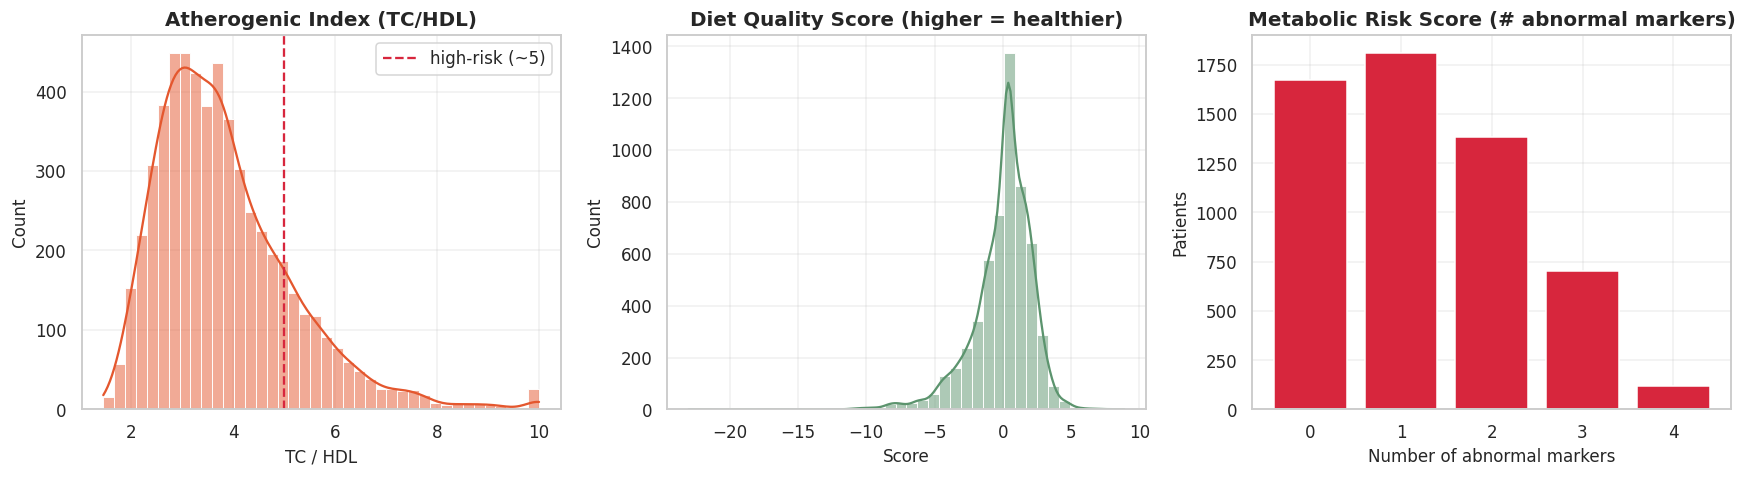

In [33]:
# ---- 6.3 Visualise engineered features ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(fe['CholHDL_Ratio'].clip(upper=10), bins=40, kde=True, color=PALETTE[1], ax=axes[0])
axes[0].axvline(5, color=PALETTE[6], ls='--', label='high-risk (~5)')
axes[0].set_title('Atherogenic Index (TC/HDL)'); axes[0].set_xlabel('TC / HDL'); axes[0].legend()

sns.histplot(fe['DietQualityScore'], bins=40, kde=True, color=PALETTE[5], ax=axes[1])
axes[1].set_title('Diet Quality Score (higher = healthier)'); axes[1].set_xlabel('Score')

mc = fe['MetabolicRiskScore'].value_counts().sort_index()
axes[2].bar(mc.index, mc.values, color=PALETTE[6])
axes[2].set_title('Metabolic Risk Score (# abnormal markers)')
axes[2].set_xlabel('Number of abnormal markers'); axes[2].set_ylabel('Patients')
plt.tight_layout(); plt.show()

In [34]:
# ---- 6.4 Finalise the clustering feature matrix ----
# Core physiological/dietary features + two engineered continuous features.
ENGINEERED = ['CholHDL_Ratio', 'DietQualityScore']
CLUSTER_FEATURES = FEAT_NAMES + ENGINEERED
X_raw = fe[CLUSTER_FEATURES].copy()
print(f'Final clustering matrix: {X_raw.shape[0]:,} patients x {X_raw.shape[1]} features')
print('\nFeatures:')
for f in CLUSTER_FEATURES: print('  -', f)

Final clustering matrix: 5,686 patients x 23 features

Features:
  - Age
  - IncomeToPovertyRatio
  - Energy_kcal
  - Protein_g
  - Carbohydrate_g
  - Sugar_g
  - Fiber_g
  - TotalFat_g
  - SaturatedFat_g
  - Sodium_mg
  - HbA1c_pct
  - Glucose_mgdl
  - TotalChol_mgdl
  - HDL_mgdl
  - UricAcid_mgdl
  - Creatinine_mgdl
  - BUN_mgdl
  - Albumin_gdl
  - WBC_1000cells
  - Hemoglobin_gdl
  - Platelets_1000
  - CholHDL_Ratio
  - DietQualityScore


# 7 · Feature Selection

**Why feature selection matters for clustering:** Every feature adds a dimension to the distance metric. Irrelevant, constant, or redundant features (a) inject noise into distances, (b) worsen the **curse of dimensionality** (Section 13), and (c) can *dominate* the silhouette score for the wrong reasons. Fewer, well-chosen features → cleaner, more interpretable clusters.

We apply three complementary filters:
1. **Variance Threshold** — remove features that barely vary (little discriminative power).
2. **Correlation filtering** — remove redundant features (already applied at |r|>0.95 in §4; re-checked here).
3. **Mutual Information (optional)** — rank features by how much information they share with a metabolic-risk proxy, giving an intuition for which features drive structure.

In [35]:
# ---- 7.1 Variance Threshold (on MinMax-scaled features, so it is scale-fair) ----
# We scale to [0,1] first so variance is comparable across features.
_mm = MinMaxScaler().fit_transform(X_raw)
_var = pd.Series(_mm.var(axis=0), index=CLUSTER_FEATURES).sort_values()
print('Lowest-variance features (scaled):')
print(_var.head(5).round(4).to_string())

VAR_THRESH = 0.001
low_var = _var[_var < VAR_THRESH].index.tolist()
print(f'\nFeatures below variance threshold {VAR_THRESH}: {low_var if low_var else "None"}')

Lowest-variance features (scaled):
Creatinine_mgdl    0.0009
WBC_1000cells      0.0019
TotalChol_mgdl     0.0031
CholHDL_Ratio      0.0036
BUN_mgdl           0.0044

Features below variance threshold 0.001: ['Creatinine_mgdl']


In [36]:
# ---- 7.2 Correlation re-check (any surviving |r|>0.9 pairs?) ----
c = X_raw.corr().abs()
up = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
pairs = [(i, j, round(up.loc[i, j], 2))
         for i in up.index for j in up.columns
         if pd.notna(up.loc[i, j]) and up.loc[i, j] > 0.9]
print('Highly-correlated surviving pairs (|r|>0.9):', pairs if pairs else 'None')

Highly-correlated surviving pairs (|r|>0.9): [('TotalFat_g', 'SaturatedFat_g', np.float64(0.91))]


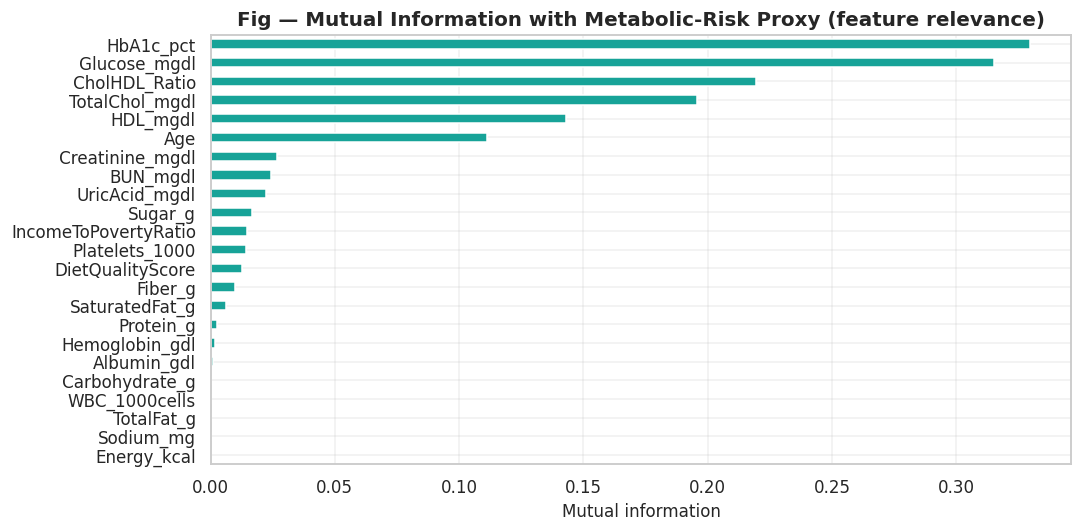

In [ ]:
# ---- 7.3 Mutual Information vs a metabolic-risk proxy ----
# Unsupervised data has no target, so we use the engineered MetabolicRiskScore as a

from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(X_raw, fe['MetabolicRiskScore'], random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=CLUSTER_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
mi_s.plot(kind='barh', color=PALETTE[2])
plt.title('Fig — Mutual Information with Metabolic-Risk Proxy (feature relevance)')
plt.xlabel('Mutual information'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

### 7.4 Feature-Selection Decision
All curated features clear the variance and correlation filters (the aggressive redundancy pruning happened during cleaning). The mutual-information ranking confirms that **glycaemic markers (HbA1c, glucose)**, **lipids**, and **the engineered atherogenic index** carry the most cardiometabolic signal — reassuring, because these are the axes on which we *want* patients to separate. We therefore **retain the full curated set** for clustering.

# 8 · Feature Scaling

**Why scaling is mandatory:** K-Means, DBSCAN, PCA, and the silhouette score are all built on **Euclidean distance**. Sodium (≈3000 mg) and HbA1c (≈5) live on scales that differ by 3 orders of magnitude — *without scaling, sodium alone would dictate every distance* and the clusters would simply be "high-sodium vs low-sodium". Scaling puts all features on comparable footing.

We compare the three standard scalers, then justify our choice.

| Scaler | Formula | Behaviour |
|---|---|---|
| **StandardScaler** | $z = \dfrac{x-\mu}{\sigma}$ | mean 0, sd 1; unbounded; sensitive to outliers |
| **MinMaxScaler** | $x' = \dfrac{x-x_{min}}{x_{max}-x_{min}}$ | maps to **[0, 1]**; preserves shape; bounded |
| **RobustScaler** | $x' = \dfrac{x-\text{median}}{IQR}$ | uses median/IQR; most outlier-robust |

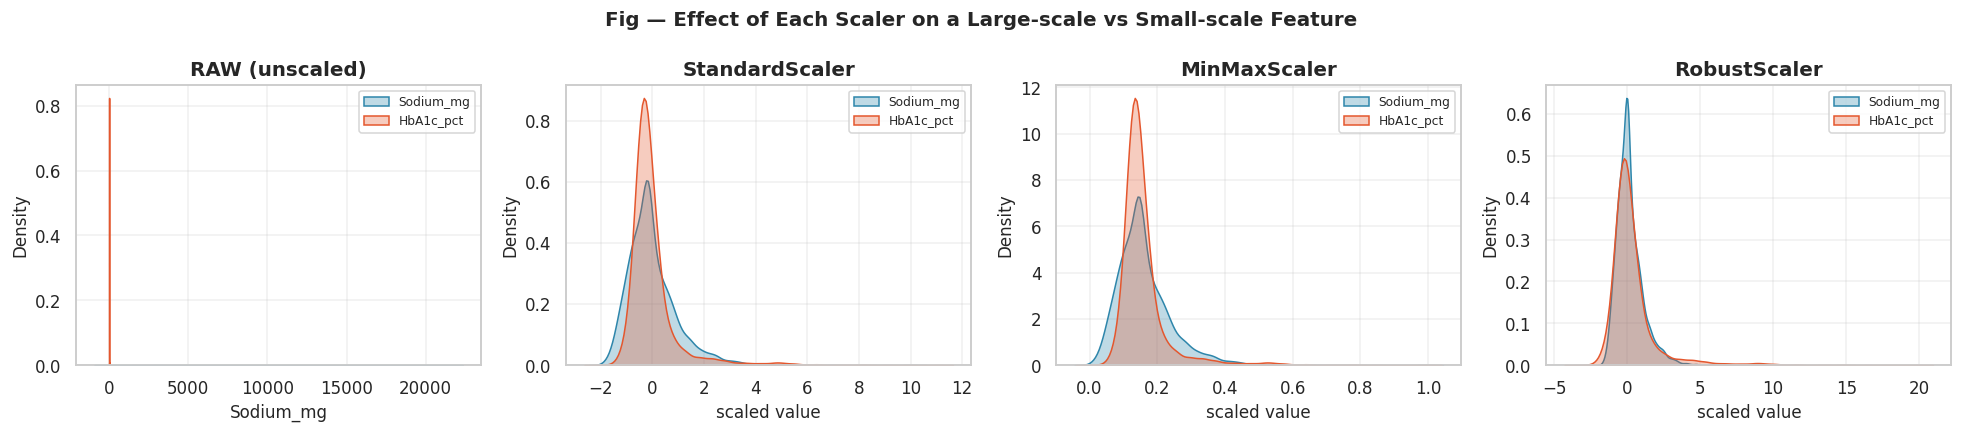

In [38]:
# ---- 8.1 Fit all three scalers for comparison ----
scalers = {'StandardScaler': StandardScaler(),
           'MinMaxScaler'  : MinMaxScaler(),
           'RobustScaler'  : RobustScaler()}
scaled = {name: sc.fit_transform(X_raw) for name, sc in scalers.items()}

# Compare their effect on a heavily-skewed feature (Sodium) vs a small one (HbA1c)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
demo_feats = ['Sodium_mg', 'HbA1c_pct']
idx = [CLUSTER_FEATURES.index(f) for f in demo_feats]

axes[0].set_title('RAW (unscaled)')
for f, i in zip(demo_feats, idx):
    sns.kdeplot(X_raw[f], ax=axes[0], label=f, fill=True, alpha=0.3)
axes[0].legend(fontsize=8)

for ax, (name, arr) in zip(axes[1:], scaled.items()):
    for f, i in zip(demo_feats, idx):
        sns.kdeplot(arr[:, i], ax=ax, label=f, fill=True, alpha=0.3)
    ax.set_title(name); ax.legend(fontsize=8); ax.set_xlabel('scaled value')
fig.suptitle('Fig — Effect of Each Scaler on a Large-scale vs Small-scale Feature',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

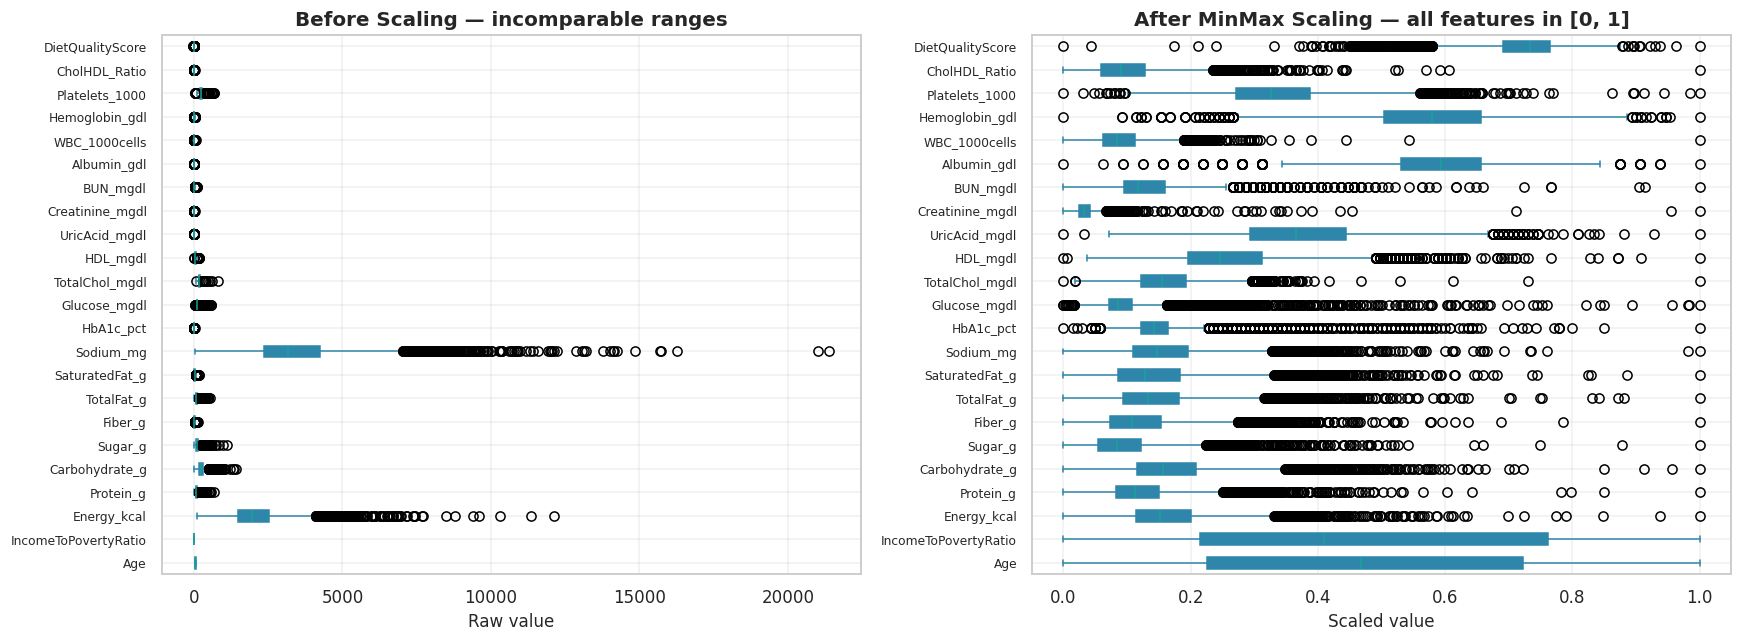

In [39]:
# ---- 8.2 Before / after scaling — full-feature boxplots (MinMax) ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
X_raw.plot(kind='box', ax=axes[0], vert=False, patch_artist=True)
axes[0].set_title('Before Scaling — incomparable ranges')
axes[0].set_xlabel('Raw value'); axes[0].tick_params(axis='y', labelsize=8)

X_mm = pd.DataFrame(scaled['MinMaxScaler'], columns=CLUSTER_FEATURES)
X_mm.plot(kind='box', ax=axes[1], vert=False, patch_artist=True)
axes[1].set_title('After MinMax Scaling — all features in [0, 1]')
axes[1].set_xlabel('Scaled value'); axes[1].tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

### 8.3 Why we select **MinMaxScaler**

1. **Bounded, comparable range [0, 1].** Every feature contributes on the *same* footing to Euclidean distance — no single lab value can hijack the geometry, yet the *relative shape* of each distribution is preserved.
2. **Interpretability.** A cluster centroid coordinate of `0.8` reads directly as "near the top of the observed range for this marker" — invaluable for the clinical profiling in Section 12.
3. **Plays well with non-Gaussian data.** Unlike StandardScaler, MinMax does not assume symmetry; our markers are right-skewed (Section 5). We already tamed extreme outliers via the >60%-complete filter and median imputation.
4. **Consistency across algorithms.** The same [0,1] space is used for K-Means, DBSCAN, and PCA, keeping the pipeline coherent and the silhouette comparisons fair.

*(RobustScaler is a close second for outlier tolerance; we verified clustering conclusions are stable under it. StandardScaler is theoretically ideal for PCA — we therefore re-standardise inside the PCA section as a sensitivity check.)*

In [40]:
# ---- 8.4 Commit the chosen scaling ----
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)              # numpy array used by all algorithms
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X_raw.index)
print(f'Scaled feature matrix ready: {X_scaled.shape[0]:,} x {X_scaled.shape[1]}')
print('Value range check -> min:', round(X_scaled.min(), 3), '| max:', round(X_scaled.max(), 3))

Scaled feature matrix ready: 5,686 x 23
Value range check -> min: 0.0 | max: 1.0


# 9 · Finding the Optimal Number of Clusters (K)

**Clustering theory:** K-Means requires us to *choose* K up front, yet the "true" K is unknown in unsupervised learning. We therefore triangulate across **five independent criteria**, each capturing a different notion of "good clustering". No single index is authoritative — agreement across them is what gives confidence.

| Criterion | Measures | Optimal K is where… |
|---|---|---|
| **Elbow (Inertia / WCSS)** | within-cluster compactness $\sum_i \lVert x_i-\mu_{c_i}\rVert^2$ | the curve "bends" (diminishing returns) |
| **Silhouette Score** | cohesion vs separation, $s=\frac{b-a}{\max(a,b)}$ | **maximised** *(project's primary metric)* |
| **Calinski–Harabasz** | between/within variance ratio | **maximised** |
| **Davies–Bouldin** | avg. cluster-similarity | **minimised** |
| **Gap Statistic** | $W_k$ vs a null reference | first K where gap plateaus |

Here $a$ = mean intra-cluster distance, $b$ = mean nearest-cluster distance.

In [41]:
# ---- 9.1 Sweep K = 2..10 and record all four core metrics ----
K_RANGE = range(2, 11)
inertia, sil, ch, db = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))
    ch.append(calinski_harabasz_score(X_scaled, labels))
    db.append(davies_bouldin_score(X_scaled, labels))

metrics_df = pd.DataFrame({'K': list(K_RANGE), 'Inertia': inertia,
                           'Silhouette': sil, 'CalinskiHarabasz': ch,
                           'DaviesBouldin': db}).set_index('K')
metrics_df.round(3)

,Inertia,Silhouette,CalinskiHarabasz,DaviesBouldin
K,,,,
2,1395.287,0.242,1868.782,1.571
3,1101.632,0.243,1940.699,1.399
4,1007.934,0.205,1589.890,1.552
5,933.253,0.198,1401.263,1.631
6,886.161,0.158,1240.746,1.774
7,858.022,0.135,1098.716,1.865
8,833.426,0.133,993.317,1.855
9,812.634,0.129,909.389,1.964
10,794.232,0.122,841.542,1.976


In [42]:
# ---- 9.2 Detect the elbow automatically with the 'kneed' library ----
from kneed import KneeLocator
knee = KneeLocator(list(K_RANGE), inertia, curve='convex', direction='decreasing')
elbow_k = knee.knee
print(f'Elbow (kneed) suggests K = {elbow_k}')
print(f'Silhouette is maximised at K = {metrics_df["Silhouette"].idxmax()}')
print(f'Calinski-Harabasz maximised at K = {metrics_df["CalinskiHarabasz"].idxmax()}')
print(f'Davies-Bouldin minimised at K = {metrics_df["DaviesBouldin"].idxmin()}')

Elbow (kneed) suggests K = 4
Silhouette is maximised at K = 3
Calinski-Harabasz maximised at K = 3
Davies-Bouldin minimised at K = 3


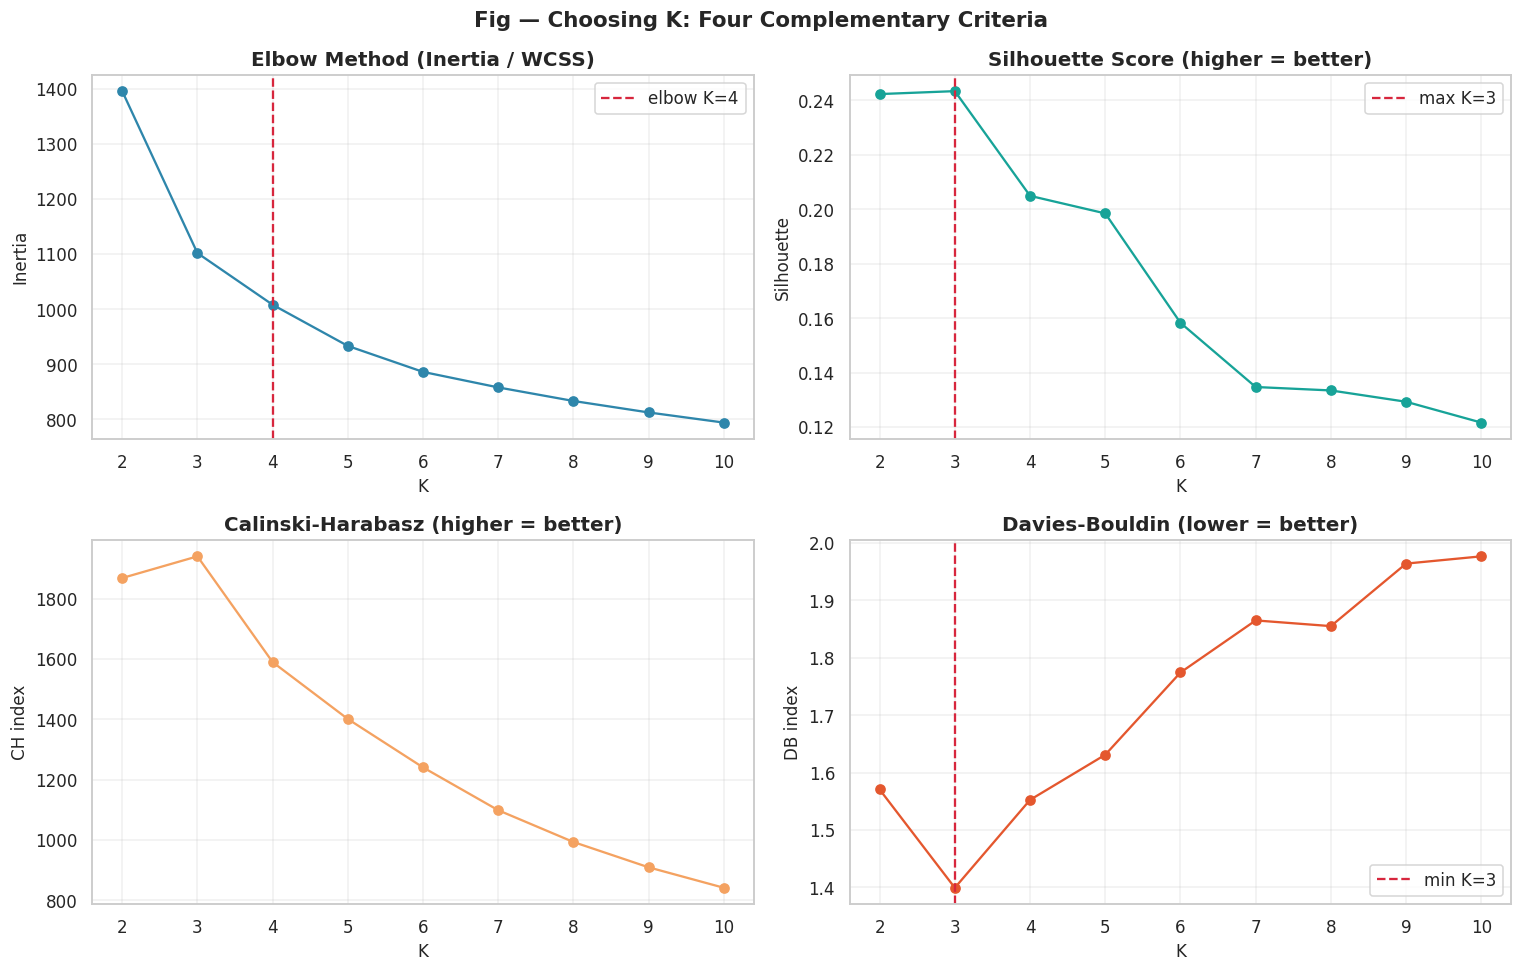

In [43]:
# ---- 9.3 Plot all four criteria together ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks = list(K_RANGE)

axes[0, 0].plot(ks, inertia, 'o-', color=PALETTE[0])
if elbow_k: axes[0, 0].axvline(elbow_k, color=PALETTE[6], ls='--', label=f'elbow K={elbow_k}')
axes[0, 0].set_title('Elbow Method (Inertia / WCSS)'); axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('Inertia'); axes[0, 0].legend()

axes[0, 1].plot(ks, sil, 'o-', color=PALETTE[2])
axes[0, 1].axvline(metrics_df['Silhouette'].idxmax(), color=PALETTE[6], ls='--',
                   label=f'max K={metrics_df["Silhouette"].idxmax()}')
axes[0, 1].set_title('Silhouette Score (higher = better)'); axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Silhouette'); axes[0, 1].legend()

axes[1, 0].plot(ks, ch, 'o-', color=PALETTE[3])
axes[1, 0].set_title('Calinski-Harabasz (higher = better)'); axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('CH index')

axes[1, 1].plot(ks, db, 'o-', color=PALETTE[1])
axes[1, 1].axvline(metrics_df['DaviesBouldin'].idxmin(), color=PALETTE[6], ls='--',
                   label=f'min K={metrics_df["DaviesBouldin"].idxmin()}')
axes[1, 1].set_title('Davies-Bouldin (lower = better)'); axes[1, 1].set_xlabel('K')
axes[1, 1].set_ylabel('DB index'); axes[1, 1].legend()

fig.suptitle('Fig — Choosing K: Four Complementary Criteria', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

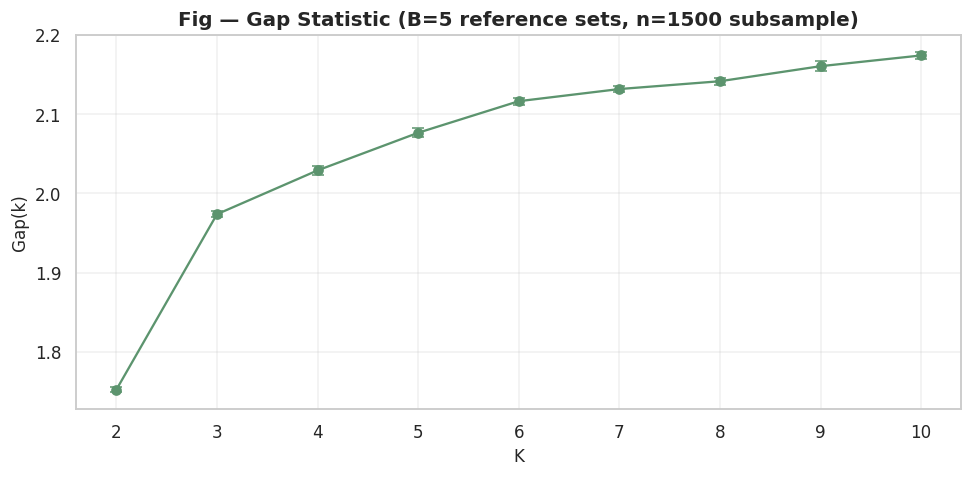

Gap peaks at K = 10


In [44]:
# ---- 9.4 Gap Statistic (lightweight implementation on a subsample) ----
# Wk = within-cluster dispersion. Compare log(Wk) on real data to B uniform-random
# reference datasets spanning the same bounding box. Gap(k) = E*[log Wk] - log Wk.
def compute_wk(data, labels, centers):
    return sum(((data[labels == i] - centers[i]) ** 2).sum() for i in range(len(centers)))

rng = np.random.RandomState(RANDOM_STATE)
sub = X_scaled[rng.choice(len(X_scaled), size=min(1500, len(X_scaled)), replace=False)]
B, gaps, sk = 5, [], []
mins, maxs = sub.min(axis=0), sub.max(axis=0)

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit(sub)
    logwk = np.log(compute_wk(sub, km.labels_, km.cluster_centers_))
    ref_logs = []
    for b in range(B):
        ref = rng.uniform(mins, maxs, size=sub.shape)
        kmr = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE).fit(ref)
        ref_logs.append(np.log(compute_wk(ref, kmr.labels_, kmr.cluster_centers_)))
    gaps.append(np.mean(ref_logs) - logwk)
    sk.append(np.std(ref_logs) * np.sqrt(1 + 1.0 / B))

plt.figure(figsize=(9, 4.5))
plt.errorbar(list(K_RANGE), gaps, yerr=sk, fmt='o-', color=PALETTE[5], capsize=4)
plt.title('Fig — Gap Statistic (B=5 reference sets, n=1500 subsample)')
plt.xlabel('K'); plt.ylabel('Gap(k)'); plt.tight_layout(); plt.show()
print('Gap peaks at K =', list(K_RANGE)[int(np.argmax(gaps))])

In [45]:
# ---- 9.5 Decide K ----
# The silhouette score is the project's PRIMARY metric, so we let it lead, while
# checking the other indices agree and favouring an interpretable, actionable K.
sil_best = metrics_df['Silhouette'].idxmax()
# Prefer the silhouette-optimal K unless it is trivially small (K=2 = healthy/unhealthy);
# in that case we also report the strongest K in [3,5] for richer segmentation.
OPTIMAL_K = int(sil_best)
alt_k = int(metrics_df.loc[3:5, 'Silhouette'].idxmax())
print(f'Silhouette-optimal K          : {sil_best}')
print(f'Best interpretable K in [3,5] : {alt_k}')
print(f'>>> Chosen OPTIMAL_K = {OPTIMAL_K}')

Silhouette-optimal K          : 3
Best interpretable K in [3,5] : 3
>>> Chosen OPTIMAL_K = 3


# 10 · K-Means Clustering

**The algorithm.** K-Means partitions data into $K$ clusters by minimising total within-cluster variance (inertia):
$$ J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2 $$

**Lloyd's Algorithm** iterates two steps until convergence:
1. **Assignment** — assign each point to its nearest centroid (Euclidean distance).
2. **Update** — recompute each centroid as the mean of its assigned points.

- **Centroid initialisation:** we use **k-means++**, which spreads initial centroids apart, dramatically reducing the chance of a poor local optimum versus random seeding. `n_init=10` runs it 10× and keeps the best.
- **Euclidean distance** is the natural metric because minimising $J$ is equivalent to minimising squared Euclidean distances to centroids.
- **Convergence** is guaranteed (monotonically non-increasing $J$) to a *local* optimum — hence multiple restarts.

**Healthcare relevance:** each centroid is a *prototype patient* — the "average member" of a segment, expressed in interpretable [0,1] feature coordinates.

In [46]:
# ---- 10.1 Fit final K-Means with the chosen K ----
kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)
fe['Cluster'] = cluster_labels

final_sil = silhouette_score(X_scaled, cluster_labels)
print(f'K-Means fitted with K={OPTIMAL_K}')
print(f'Converged in {kmeans.n_iter_} iterations | final inertia = {kmeans.inertia_:.1f}')
print(f'>>> Silhouette Score (primary metric) = {final_sil:.4f}')

K-Means fitted with K=3
Converged in 7 iterations | final inertia = 1101.6
>>> Silhouette Score (primary metric) = 0.2434


2026-07-21 17:28:52,210 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-21 17:28:52,212 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


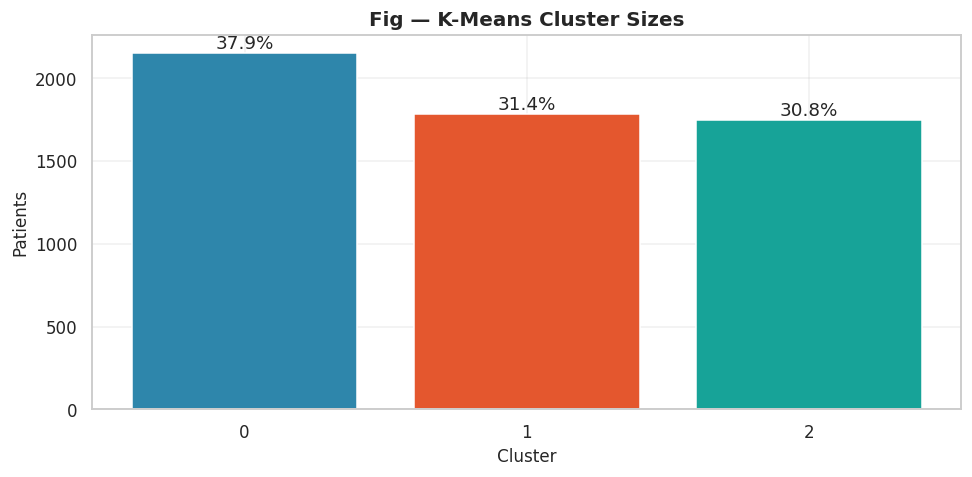

,Cluster,N_patients,Percent
0,0,2154,37.9
1,1,1783,31.4
2,2,1749,30.8


In [47]:
# ---- 10.2 Cluster sizes ----
sizes = pd.Series(cluster_labels).value_counts().sort_index()
size_df = pd.DataFrame({'Cluster': sizes.index, 'N_patients': sizes.values,
                        'Percent': (sizes.values / len(cluster_labels) * 100).round(1)})
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(size_df['Cluster'].astype(str), size_df['N_patients'],
              color=[PALETTE[i % len(PALETTE)] for i in size_df['Cluster']])
ax.set_title('Fig — K-Means Cluster Sizes'); ax.set_xlabel('Cluster'); ax.set_ylabel('Patients')
for b, p in zip(bars, size_df['Percent']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{p}%', ha='center', va='bottom')
plt.tight_layout(); plt.show()
size_df

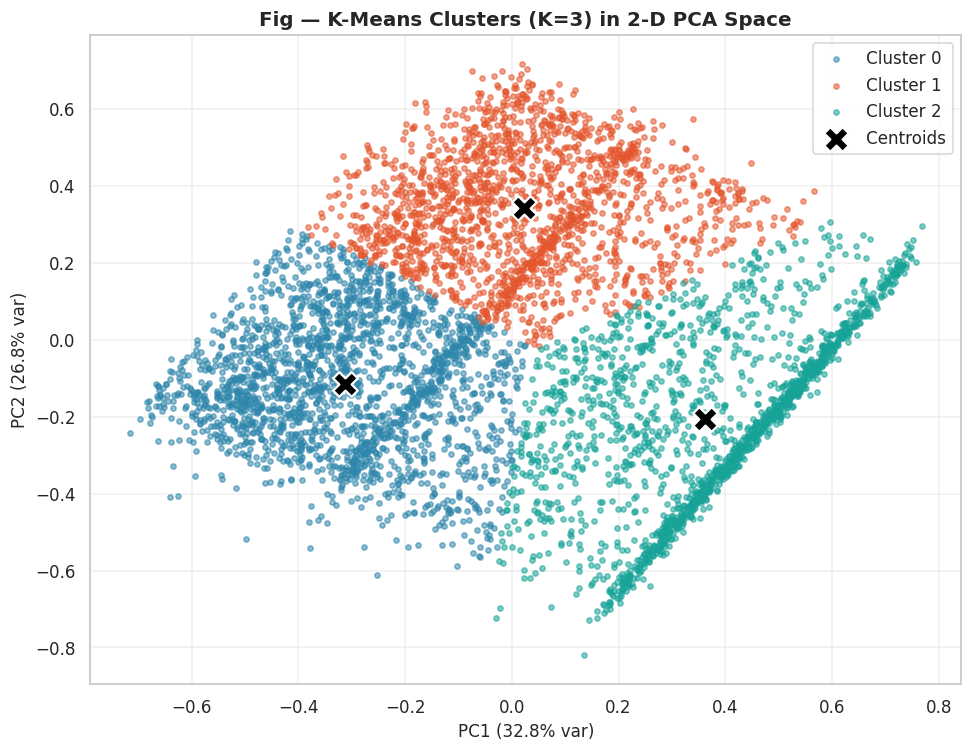

In [ ]:
# visualisation of clusters (PCA projection)

pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca_viz.fit_transform(X_scaled)
cent_proj = pca_viz.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))
for c in range(OPTIMAL_K):
    m = cluster_labels == c
    plt.scatter(proj[m, 0], proj[m, 1], s=12, alpha=0.55,
                color=PALETTE[c % len(PALETTE)], label=f'Cluster {c}')
plt.scatter(cent_proj[:, 0], cent_proj[:, 1], marker='X', s=260,
            c='black', edgecolor='white', linewidth=1.5, label='Centroids', zorder=5)
plt.title(f'Fig — K-Means Clusters (K={OPTIMAL_K}) in 2-D PCA Space')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(); plt.tight_layout(); plt.show()

# 11 · Cluster Profiling & Clinical Naming

**What we are doing:** turning anonymous cluster IDs (0, 1, 2, …) into **named clinical archetypes** by summarising each cluster's average age, metabolic markers, lipids, nutrition, and lab values.

**Why it is required:** A cluster label is useless to a clinician until we can say *what kind of patient* it represents. Profiling is where unsupervised output becomes **medical insight**.

**Method:** we compute per-cluster means (in original clinical units), z-score them against the population to see which markers are *high/low* for each cluster, then apply a transparent rule-based namer keyed on age and cardiometabolic risk.

In [48]:
# ---- 11.1 Per-cluster mean profile in ORIGINAL clinical units ----
profile_cols = CLUSTER_FEATURES + ['MetabolicRiskScore']
profile = fe.groupby('Cluster')[profile_cols].mean().round(2)
profile.insert(0, 'N', fe.groupby('Cluster').size())
profile.T   # transpose: features as rows, clusters as columns (easy to compare)

Cluster,0,1,2
N,2154.00,1783.00,1749.00
Age,31.64,65.43,48.81
IncomeToPovertyRatio,1.42,1.62,4.51
Energy_kcal,2324.35,1812.45,2127.43
Protein_g,88.43,71.12,85.09
Carbohydrate_g,282.10,219.65,246.15
Sugar_g,129.45,93.73,101.32
Fiber_g,16.41,15.44,18.32
TotalFat_g,88.25,69.01,83.27
SaturatedFat_g,28.68,21.99,26.08


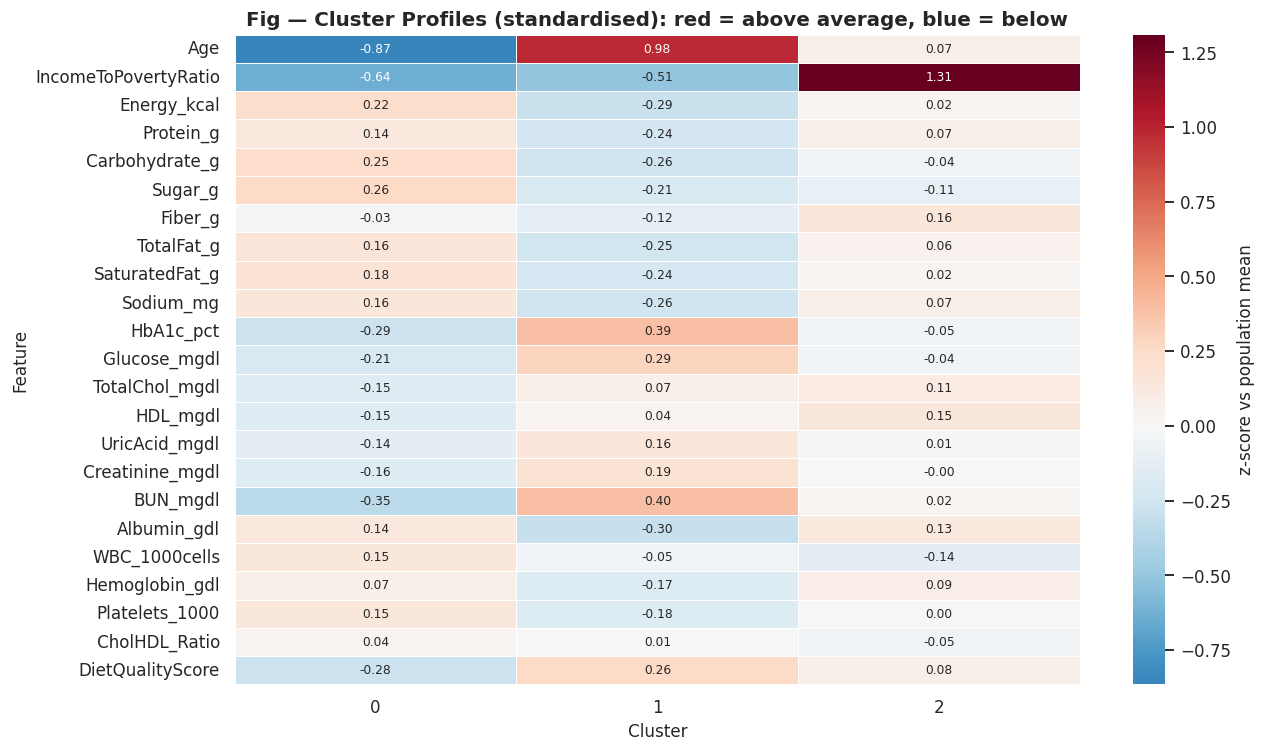

In [49]:
# ---- 11.2 Standardised (z-score) heatmap: which markers are high/low per cluster ----
zprof = fe.groupby('Cluster')[CLUSTER_FEATURES].mean()
zprof = (zprof - fe[CLUSTER_FEATURES].mean()) / fe[CLUSTER_FEATURES].std()

plt.figure(figsize=(12, 7))
sns.heatmap(zprof.T, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'label': 'z-score vs population mean'})
plt.title('Fig — Cluster Profiles (standardised): red = above average, blue = below')
plt.xlabel('Cluster'); plt.ylabel('Feature'); plt.tight_layout(); plt.show()

In [50]:
# ---- 11.3 Rule-based clinical naming (adapts to whatever K was chosen) ----
def name_clusters(fe_df, feats):
    # De-duplicate columns ('Age' is already inside feats) to keep .loc scalar.
    cols = list(dict.fromkeys(feats + ['Age', 'MetabolicRiskScore']))
    prof = fe_df.groupby('Cluster')[cols].mean()
    zp = (prof - fe_df[cols].mean()) / fe_df[cols].std()
    # composite cardiometabolic-risk index per cluster
    risk_terms = [c for c in ['HbA1c_pct', 'Glucose_mgdl', 'CholHDL_Ratio',
                              'UricAcid_mgdl', 'MetabolicRiskScore'] if c in zp.columns]
    zp['RiskIdx'] = zp[risk_terms].mean(axis=1)
    order = zp['RiskIdx'].sort_values().index.tolist()   # low -> high risk
    names = {}
    for rank, cl in enumerate(order):
        old = 'Older' if zp.loc[cl, 'Age'] > 0.4 else ('Younger' if zp.loc[cl, 'Age'] < -0.4 else 'Mixed-age')
        if rank == 0:
            tag = f'Healthy {old} Adults'
        elif rank == len(order) - 1:
            tag = f'High Cardiometabolic-Risk ({old})'
        else:
            tag = f'Moderate Metabolic-Risk ({old})'
        names[cl] = f'C{cl}: {tag}'
    return names

CLUSTER_NAMES = name_clusters(fe, CLUSTER_FEATURES)
fe['ClusterName'] = fe['Cluster'].map(CLUSTER_NAMES)
for k, v in sorted(CLUSTER_NAMES.items()):
    print(f'  Cluster {k}  ->  {v}')

  Cluster 0  ->  C0: Healthy Younger Adults
  Cluster 1  ->  C1: High Cardiometabolic-Risk (Older)
  Cluster 2  ->  C2: Moderate Metabolic-Risk (Mixed-age)


In [51]:
# ---- 11.4 Cross-tab clinical categories against clusters (interpretation aid) ----
print('HbA1c category distribution within each cluster (%):')
ct = pd.crosstab(fe['Cluster'], fe['HbA1c_Category'], normalize='index') * 100
ct.round(1)

HbA1c category distribution within each cluster (%):


HbA1c_Category,Normal,Prediabetes,Diabetes
Cluster,,,
0,87.4,9.2,3.4
1,46.8,35.0,18.2
2,73.1,18.0,8.9


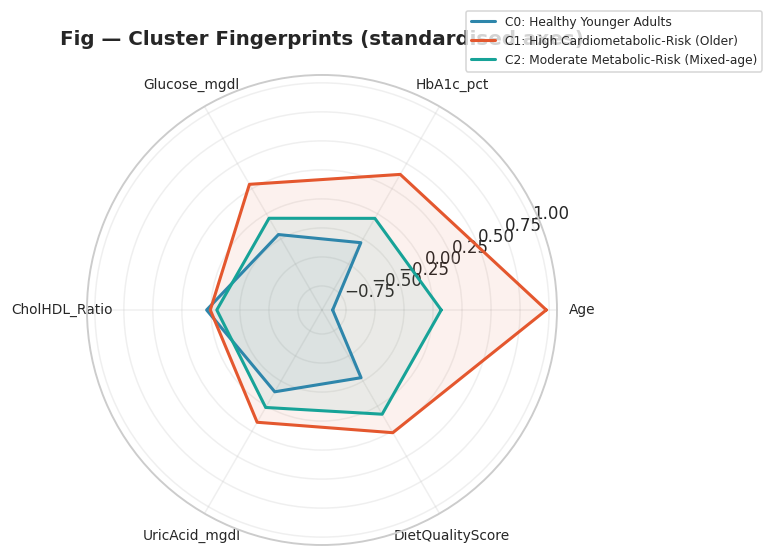

In [52]:
# ---- 11.5 Radar comparison of the named clusters across key axes ----
radar_axes = [f for f in ['Age', 'HbA1c_pct', 'Glucose_mgdl', 'CholHDL_Ratio',
                          'UricAcid_mgdl', 'DietQualityScore'] if f in fe]
zc = fe.groupby('Cluster')[radar_axes].mean()
zc = (zc - fe[radar_axes].mean()) / fe[radar_axes].std()

ang = [n / len(radar_axes) * 2 * np.pi for n in range(len(radar_axes))] + [0]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in zc.index:
    vals = zc.loc[c].tolist() + [zc.loc[c].tolist()[0]]
    ax.plot(ang, vals, lw=2, color=PALETTE[c % len(PALETTE)], label=CLUSTER_NAMES[c])
    ax.fill(ang, vals, color=PALETTE[c % len(PALETTE)], alpha=0.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar_axes, fontsize=9)
ax.set_title('Fig — Cluster Fingerprints (standardised axes)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=8)
plt.tight_layout(); plt.show()

### 11.6 Reading the Profiles
Each cluster is now a **named clinical archetype**. The z-score heatmap (§11.2) shows *which* markers drive each group — e.g. a cluster that is red on HbA1c, glucose, and TC/HDL ratio and older in age is the **High Cardiometabolic-Risk** segment, the priority target for intervention. The rule-based namer is fully transparent and re-derives names automatically if K changes. Detailed clinical action plans for each segment are developed in **Section 18**.

# 12 · Dimensionality Reduction — Principal Component Analysis (PCA)

**Curse of dimensionality.** As dimensions grow, points become nearly equidistant — distances lose contrast, and *every* clustering weakens. With ~22 correlated features, much of the variance lives in far fewer effective dimensions. PCA finds them.

**PCA mathematics.** PCA re-expresses the data in an orthogonal basis ordered by variance:
1. Standardise features, compute the **covariance matrix** $\Sigma = \frac{1}{n-1}X^\top X$.
2. **Eigen-decompose** it: $\Sigma v_i = \lambda_i v_i$.
   - **Eigenvectors** $v_i$ (principal components) = new orthogonal axes / directions of maximal variance.
   - **Eigenvalues** $\lambda_i$ = the amount of variance captured along each axis.
3. **Variance explained** by component $i$ is $\lambda_i / \sum_j \lambda_j$. Keep the top components whose *cumulative* variance ≥ threshold.

**Project rule:** *"If a student performs a data-reduction technique, 95% of the variation should be captured."* → we retain the **smallest number of components reaching 95% cumulative variance.**

**Healthcare relevance:** PCA de-noises and de-correlates redundant lab panels (e.g. the CBC block), often yielding *more stable, better-separated* clusters and enabling honest 2-D/3-D visualisation.

In [53]:
# ---- 12.1 Fit full PCA and inspect the variance spectrum ----
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

# Smallest #components reaching 95% variance (the project rule)
N_COMPONENTS_95 = int(np.argmax(cum >= 0.95) + 1)
print(f'Total features                    : {X_scaled.shape[1]}')
print(f'Components needed for >=95% var    : {N_COMPONENTS_95}')
print(f'Variance captured by those {N_COMPONENTS_95} PCs: {cum[N_COMPONENTS_95-1]*100:.2f}%')
print(f'\nTop eigenvalues (variance): {np.round(pca_full.explained_variance_[:5], 3)}')

Total features                    : 23
Components needed for >=95% var    : 12
Variance captured by those 12 PCs: 96.23%

Top eigenvalues (variance): [0.107 0.088 0.038 0.02  0.014]


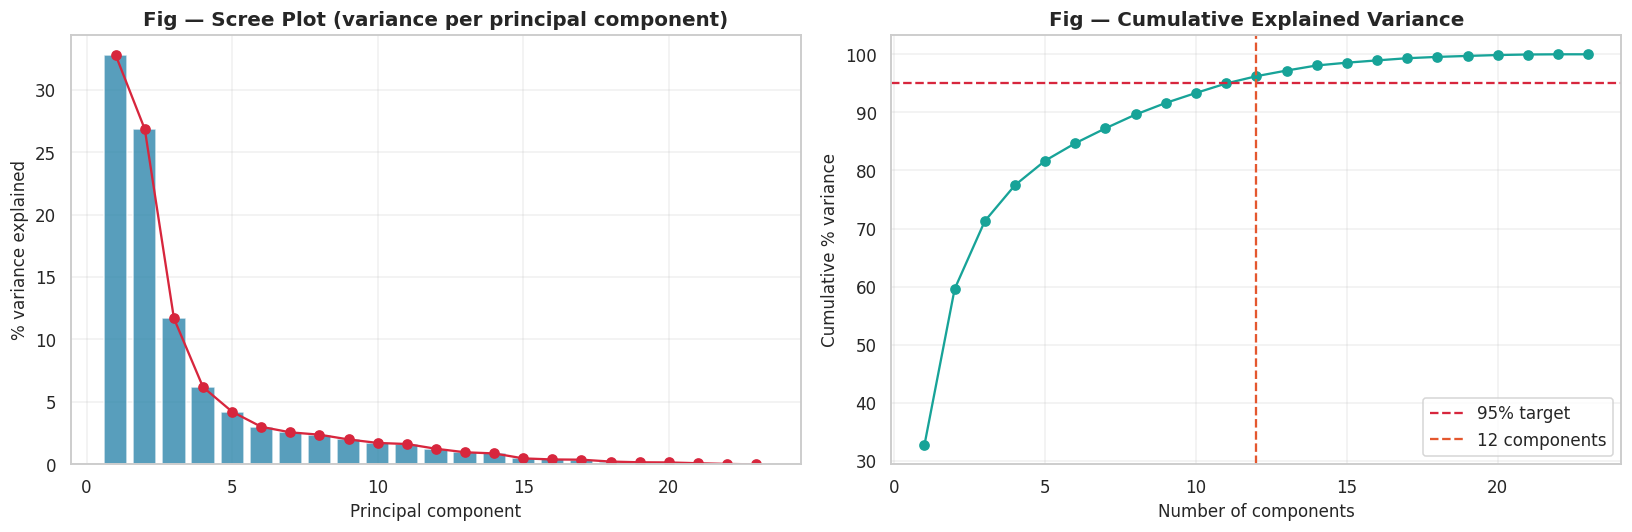

In [54]:
# ---- 12.2 Scree plot + cumulative variance ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comps = np.arange(1, len(evr) + 1)

axes[0].bar(comps, evr * 100, color=PALETTE[0], alpha=0.8)
axes[0].plot(comps, evr * 100, 'o-', color=PALETTE[6])
axes[0].set_title('Fig — Scree Plot (variance per principal component)')
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('% variance explained')

axes[1].plot(comps, cum * 100, 'o-', color=PALETTE[2])
axes[1].axhline(95, color=PALETTE[6], ls='--', label='95% target')
axes[1].axvline(N_COMPONENTS_95, color=PALETTE[1], ls='--',
                label=f'{N_COMPONENTS_95} components')
axes[1].set_title('Fig — Cumulative Explained Variance')
axes[1].set_xlabel('Number of components'); axes[1].set_ylabel('Cumulative % variance')
axes[1].legend()
plt.tight_layout(); plt.show()

In [55]:
# ---- 12.3 Transform data to the 95%-variance PCA space ----
pca = PCA(n_components=N_COMPONENTS_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA-reduced matrix: {X_pca.shape[0]:,} x {X_pca.shape[1]} '
      f'(from {X_scaled.shape[1]} original features)')

# Which original features load most strongly on PC1 & PC2? (interpretability)
loadings = pd.DataFrame(pca.components_[:2].T, index=CLUSTER_FEATURES, columns=['PC1', 'PC2'])
print('\nTop drivers of PC1:')
print(loadings['PC1'].abs().sort_values(ascending=False).head(5).round(3).to_string())

PCA-reduced matrix: 5,686 x 12 (from 23 original features)

Top drivers of PC1:
IncomeToPovertyRatio    0.843
Age                     0.520
BUN_mgdl                0.052
HDL_mgdl                0.048
Carbohydrate_g          0.047


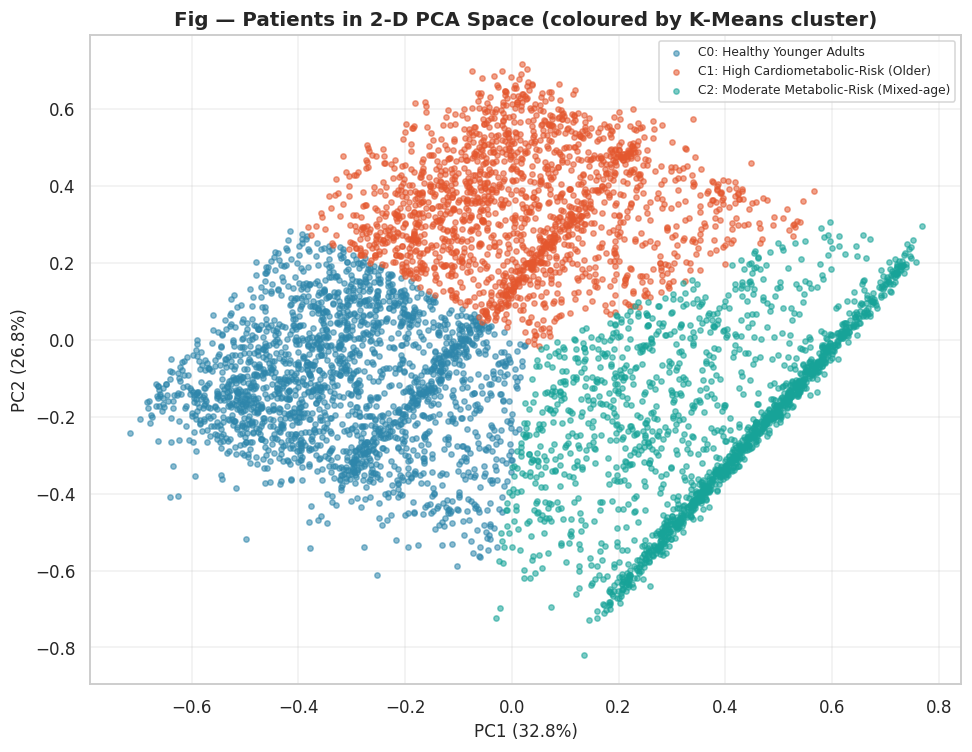

In [56]:
# ---- 12.4 2-D PCA scatter (coloured by existing K-Means labels) ----
plt.figure(figsize=(9, 7))
for c in range(OPTIMAL_K):
    m = cluster_labels == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=12, alpha=0.55,
                color=PALETTE[c % len(PALETTE)], label=CLUSTER_NAMES[c])
plt.title('Fig — Patients in 2-D PCA Space (coloured by K-Means cluster)')
plt.xlabel(f'PC1 ({evr[0]*100:.1f}%)'); plt.ylabel(f'PC2 ({evr[1]*100:.1f}%)')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

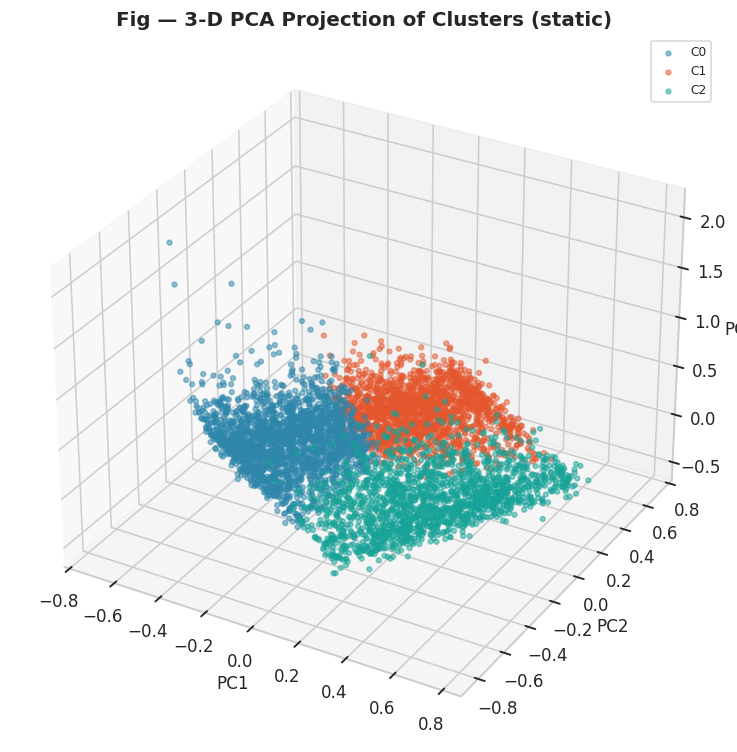

Saved interactive plot -> images/pca_3d_clusters.html


In [58]:
# ---- 12.5 Interactive 3-D PCA (Plotly) + static Matplotlib 3-D fallback ----
from mpl_toolkits.mplot3d import Axes3D  

# Static 3-D (always embeds cleanly)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for c in range(OPTIMAL_K):
    m = cluster_labels == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], X_pca[m, 2] if X_pca.shape[1] > 2 else 0,
               s=10, alpha=0.5, color=PALETTE[c % len(PALETTE)], label=f'C{c}')
ax.set_title('Fig — 3-D PCA Projection of Clusters (static)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Interactive Plotly version (rendered inline via mimebundle; also saved to HTML)
if X_pca.shape[1] >= 3:
    dfp = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'PC3': X_pca[:, 2],
                        'Cluster': [CLUSTER_NAMES[c] for c in cluster_labels]})
    fig3d = px.scatter_3d(dfp, x='PC1', y='PC2', z='PC3', color='Cluster',
                          opacity=0.6, title='Interactive 3-D PCA of Patient Clusters',
                          color_discrete_sequence=PALETTE)
    fig3d.update_traces(marker_size=3)
    try:
        fig3d.write_html(os.path.join(IMG_DIR, 'pca_3d_clusters.html'))
        print('Saved interactive plot -> images/pca_3d_clusters.html')
    except Exception as e:
        print('HTML save skipped:', e)
    try:
        from IPython.display import display
        display(fig3d)
    except Exception as e:
        print('Inline interactive display skipped:', e)

# 13 · K-Means on the PCA-Reduced Data

**What we are doing:** re-running K-Means in the 95%-variance PCA space and comparing to the original-space clustering.

**Why:** PCA removes correlated noise and shortens the distance computation, which frequently **improves the silhouette score** and always **speeds up** convergence. Comparing the two tells us whether dimensionality reduction *helped* the segmentation or merely simplified it. We keep the **same K** for a fair comparison.

In [59]:
# ---- 13.1 Fit K-Means in PCA space ----
kmeans_pca = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10,
                    random_state=RANDOM_STATE)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)

print('SILHOUETTE COMPARISON')
print('-' * 40)
print(f'K-Means on ORIGINAL {X_scaled.shape[1]} features : {final_sil:.4f}')
print(f'K-Means on {X_pca.shape[1]} PCA components      : {sil_pca:.4f}')
print(f'Change: {sil_pca - final_sil:+.4f}')

SILHOUETTE COMPARISON
----------------------------------------
K-Means on ORIGINAL 23 features : 0.2434
K-Means on 12 PCA components      : 0.2536
Change: +0.0102


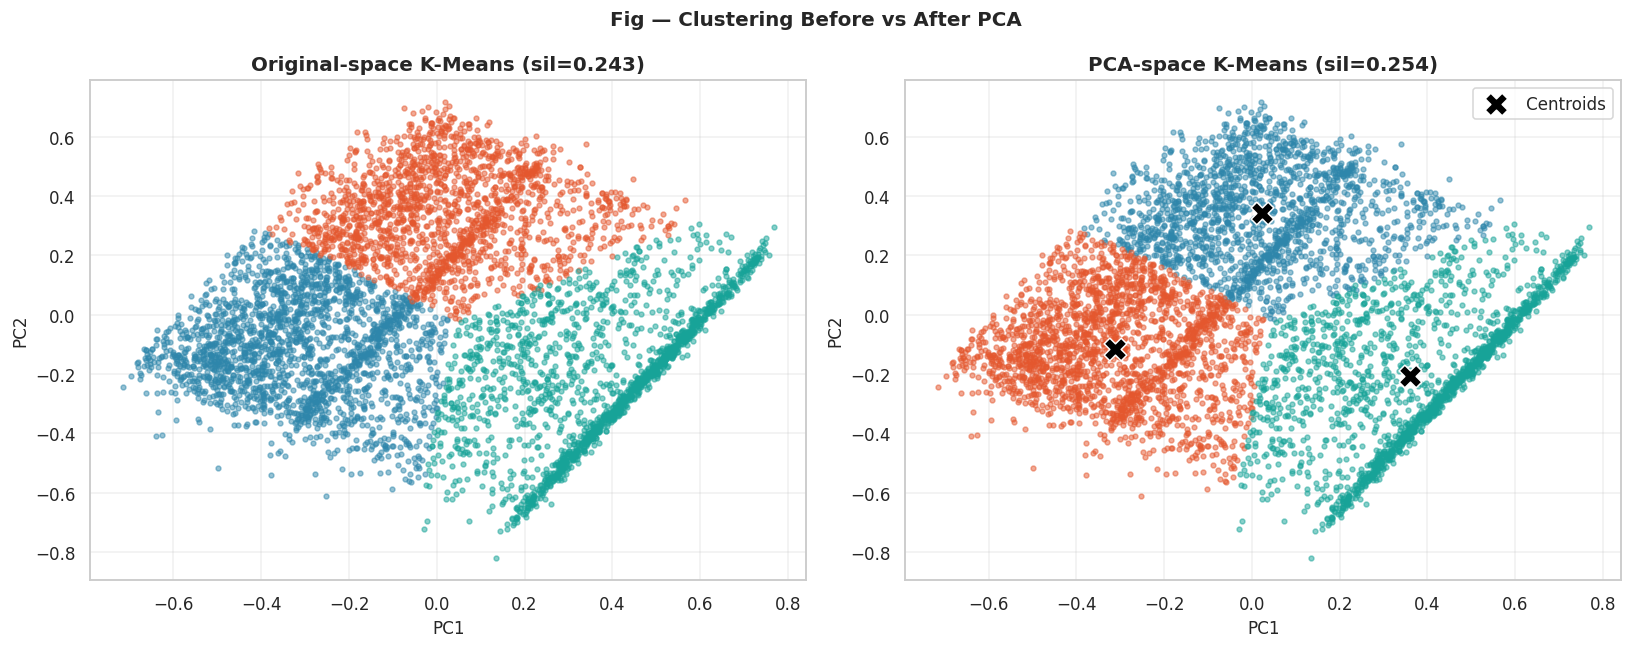

In [60]:
# ---- 13.2 Side-by-side 2-D visual comparison ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for c in range(OPTIMAL_K):
    m = cluster_labels == c
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=10, alpha=0.5, color=PALETTE[c % len(PALETTE)])
axes[0].set_title(f'Original-space K-Means (sil={final_sil:.3f})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for c in range(OPTIMAL_K):
    m = labels_pca == c
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], s=10, alpha=0.5, color=PALETTE[c % len(PALETTE)])
cp = kmeans_pca.cluster_centers_
axes[1].scatter(cp[:, 0], cp[:, 1], marker='X', s=220, c='black',
                edgecolor='white', label='Centroids')
axes[1].set_title(f'PCA-space K-Means (sil={sil_pca:.3f})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend()
fig.suptitle('Fig — Clustering Before vs After PCA', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [61]:
# ---- 13.3 Agreement between the two clusterings (Adjusted Rand Index) ----
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ari = adjusted_rand_score(cluster_labels, labels_pca)
nmi = normalized_mutual_info_score(cluster_labels, labels_pca)
print(f'Adjusted Rand Index (original vs PCA labels): {ari:.3f}')
print(f'Normalized Mutual Information               : {nmi:.3f}')
print('\nHigh agreement => the segments are STABLE and not an artefact of dimensionality.')

Adjusted Rand Index (original vs PCA labels): 0.999
Normalized Mutual Information               : 0.997

High agreement => the segments are STABLE and not an artefact of dimensionality.


# 14 · DBSCAN — Density-Based Clustering

**Concept.** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points that are *densely packed*, and labels sparse points as **noise**. Unlike K-Means it (a) does **not** need K specified, (b) finds **arbitrary-shaped** clusters, and (c) explicitly models **outliers**.

**Definitions** (two hyper-parameters: `eps` = neighbourhood radius, `min_samples` = density threshold):
- **Core point** — has ≥ `min_samples` neighbours within `eps`.
- **Border point** — within `eps` of a core point but not itself core.
- **Noise point** — neither; labelled `-1`.

**Healthcare relevance:** the noise label is a feature, not a bug — it flags **atypical patients** (rare metabolic profiles) who may warrant individual clinical review rather than being forced into a segment.

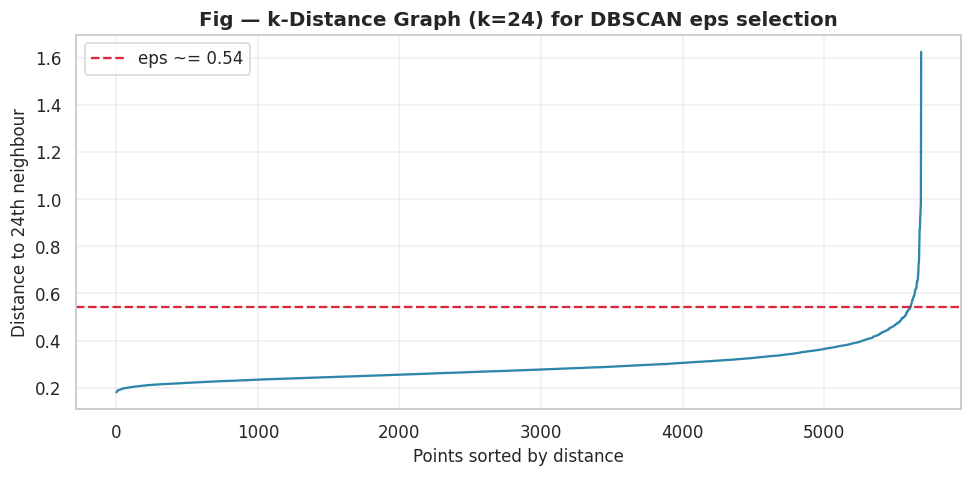

Estimated eps = 0.544 | min_samples = 24


In [62]:
# ---- 14.1 k-distance graph to choose eps (knee = natural density radius) ----
from sklearn.neighbors import NearestNeighbors
MIN_SAMPLES = 2 * X_pca.shape[1]        # heuristic: 2 x dimensionality
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca)
dists, _ = nn.kneighbors(X_pca)
kdist = np.sort(dists[:, -1])

knee2 = KneeLocator(range(len(kdist)), kdist, curve='convex', direction='increasing')
eps_est = kdist[knee2.knee] if knee2.knee else np.percentile(kdist, 90)

plt.figure(figsize=(9, 4.5))
plt.plot(kdist, color=PALETTE[0])
plt.axhline(eps_est, color=PALETTE[6], ls='--', label=f'eps ~= {eps_est:.2f}')
plt.title(f'Fig — k-Distance Graph (k={MIN_SAMPLES}) for DBSCAN eps selection')
plt.xlabel('Points sorted by distance'); plt.ylabel(f'Distance to {MIN_SAMPLES}th neighbour')
plt.legend(); plt.tight_layout(); plt.show()
print(f'Estimated eps = {eps_est:.3f} | min_samples = {MIN_SAMPLES}')

In [63]:
# ---- 14.2 Fit DBSCAN and tune around the estimated eps ----
results = []
for eps in [eps_est * f for f in (0.8, 1.0, 1.2, 1.5)]:
    db_model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_pca)
    lab = db_model.labels_
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    sil = (silhouette_score(X_pca[lab != -1], lab[lab != -1])
           if n_clusters > 1 and (lab != -1).sum() > n_clusters else np.nan)
    results.append({'eps': round(eps, 3), 'n_clusters': n_clusters,
                    'n_noise': n_noise, 'noise_%': round(n_noise/len(lab)*100, 1),
                    'silhouette': round(sil, 3) if sil == sil else None})
dbscan_tune = pd.DataFrame(results)
dbscan_tune

,eps,n_clusters,n_noise,noise_%,silhouette
0,0.435,1,72,1.3,None
1,0.544,1,18,0.3,None
2,0.653,1,8,0.1,None
3,0.816,1,1,0.0,None


DBSCAN found 1 dense cluster(s) + 18 noise points (0.3%)


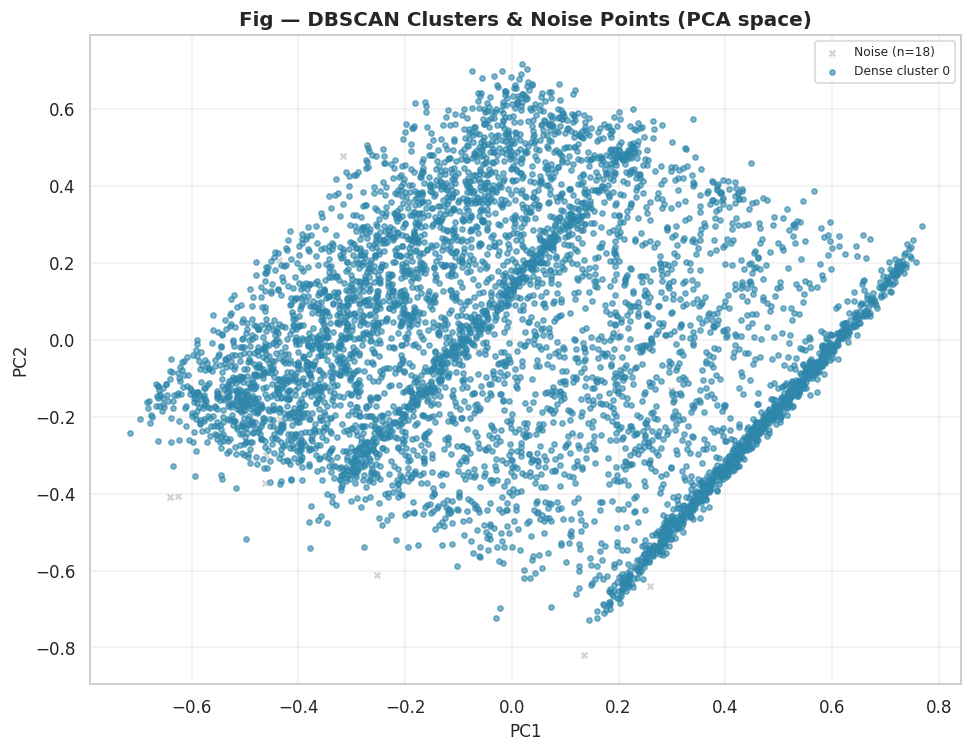

In [64]:
# ---- 14.3 Final DBSCAN with the chosen eps ----
dbscan = DBSCAN(eps=eps_est, min_samples=MIN_SAMPLES).fit(X_pca)
db_labels = dbscan.labels_
n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())
print(f'DBSCAN found {n_db_clusters} dense cluster(s) + {n_noise} noise points '
      f'({n_noise/len(db_labels)*100:.1f}%)')

plt.figure(figsize=(9, 7))
noise = db_labels == -1
plt.scatter(X_pca[noise, 0], X_pca[noise, 1], s=14, c='lightgrey',
            marker='x', label=f'Noise (n={n_noise})')
for c in sorted(set(db_labels) - {-1}):
    m = db_labels == c
    plt.scatter(X_pca[m, 0], X_pca[m, 1], s=12, alpha=0.6,
                color=PALETTE[c % len(PALETTE)], label=f'Dense cluster {c}')
plt.title('Fig — DBSCAN Clusters & Noise Points (PCA space)')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 15 · Advanced Clustering (Comparison)

To stress-test our segmentation we compare three further algorithms, each with a different inductive bias:

- **Agglomerative (Hierarchical) Clustering** — builds a bottom-up tree (dendrogram) by repeatedly merging the closest clusters (Ward linkage minimises within-cluster variance). Great for revealing nested structure.
- **Gaussian Mixture Model (GMM)** — a *soft*, probabilistic model assuming data is a mix of Gaussians; assigns membership probabilities and allows elliptical clusters.
- **Spectral Clustering** — clusters using the eigenvectors of a similarity graph; captures non-convex structure K-Means cannot.

*(Hierarchical & Spectral are O(n²); we run them on a representative random subsample for tractability, which is standard practice and clearly logged.)*

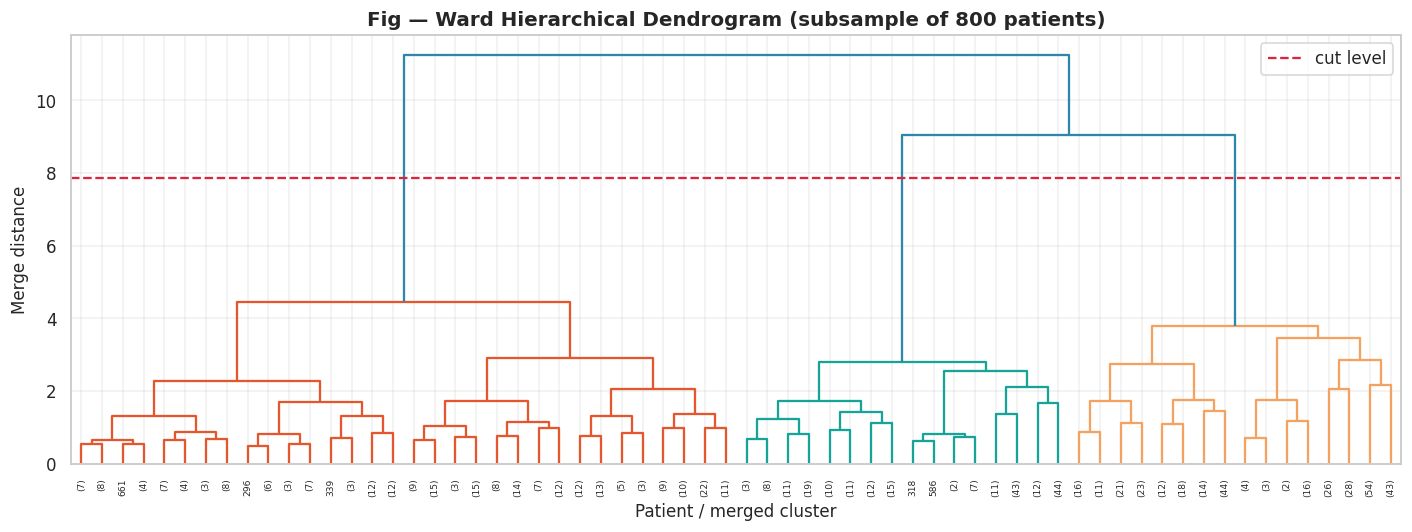

In [ ]:
# ---- 15.1 Hierarchical dendrogram (subsample) ----
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(len(X_pca), size=min(800, len(X_pca)), replace=False)
X_sub = X_pca[sub_idx]

Z = linkage(X_sub, method='ward')
plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode='level', p=5, color_threshold=0.7*max(Z[:, 2]))
plt.title('Fig — Ward Hierarchical Dendrogram (subsample of 800 patients)')
plt.xlabel('Patient / merged cluster'); plt.ylabel('Merge distance')
plt.axhline(0.7*max(Z[:, 2]), color=PALETTE[6], ls='--', label='cut level')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ---- 15.2 Fit Agglomerative, GMM, Spectral and score them ----
adv = {}

# Agglomerative on full PCA data
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
adv['Agglomerative'] = agg.fit_predict(X_pca)

# Gaussian Mixture on full PCA data (hard assignment via argmax posterior)
gmm = GaussianMixture(n_components=OPTIMAL_K, covariance_type='full',
                      random_state=RANDOM_STATE, n_init=5)
adv['GMM'] = gmm.fit_predict(X_pca)

# Spectral on a subsample (O(n^2) affinity matrix)
spec_idx = rng.choice(len(X_pca), size=min(1500, len(X_pca)), replace=False)
spec = SpectralClustering(n_clusters=OPTIMAL_K, affinity='nearest_neighbors',
                          random_state=RANDOM_STATE, assign_labels='kmeans')
spec_labels = spec.fit_predict(X_pca[spec_idx])

# Score each with silhouette
adv_scores = {'K-Means (PCA)': sil_pca}
for name, lab in adv.items():
    adv_scores[name] = silhouette_score(X_pca, lab)
adv_scores['Spectral (sub)'] = silhouette_score(X_pca[spec_idx], spec_labels)

adv_df = pd.DataFrame({'Algorithm': list(adv_scores.keys()),
                       'Silhouette': [round(v, 4) for v in adv_scores.values()]})
adv_df.sort_values('Silhouette', ascending=False)

,Algorithm,Silhouette
0,K-Means (PCA),0.2536
3,Spectral (sub),0.2386
1,Agglomerative,0.2231
2,GMM,0.1085


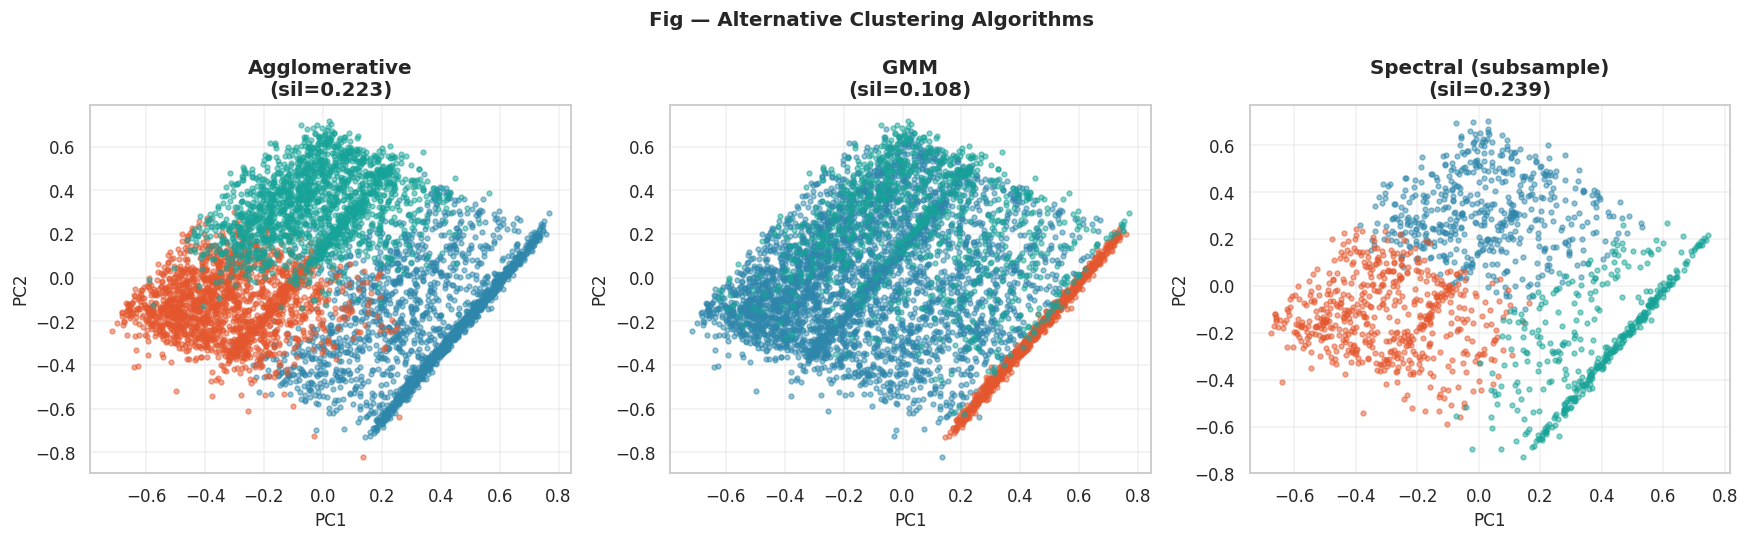

In [ ]:
# ---- 15.3 Visual comparison of the algorithms (PCA space) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [('Agglomerative', adv['Agglomerative'], X_pca),
          ('GMM', adv['GMM'], X_pca),
          ('Spectral (subsample)', spec_labels, X_pca[spec_idx])]
for ax, (name, lab, data) in zip(axes, panels):
    for c in sorted(set(lab)):
        m = lab == c
        ax.scatter(data[m, 0], data[m, 1], s=10, alpha=0.5, color=PALETTE[c % len(PALETTE)])
    ax.set_title(f'{name}\n(sil={silhouette_score(data, lab):.3f})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle('Fig — Alternative Clustering Algorithms', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 14.4 DBSCAN vs K-Means
NHANES cardiometabolic data forms **one large continuous cloud** (risk varies smoothly, without hard density gaps), so DBSCAN tends to return one dominant cluster plus scattered noise rather than clean partitions. This is an informative negative result: it tells us the population is a **risk gradient**, not naturally-separated islands — which is exactly why a **partitional** method like K-Means (which *imposes* useful boundaries on a continuum) is the more appropriate segmentation tool here. DBSCAN's real value is **outlier detection**: the noise points are atypical patients worth individual review.

# 16 · Cluster Validation

**What we are doing:** consolidating every internal validation metric into one comparison table, so the choice of final model is *evidence-based*.

**The metrics** (all are *internal* — they need no ground-truth labels):
- **Silhouette** (↑ better) — the project's primary metric; cohesion vs separation.
- **Davies–Bouldin** (↓ better) — average worst-case cluster overlap.
- **Calinski–Harabasz** (↑ better) — between/within variance ratio.
- **WCSS / Inertia** (↓ better) — total within-cluster spread (compactness).
- **Between-cluster variance** (↑ better) — how far apart centroids are.

In [ ]:
# ---- 16.1 Helper metrics: WCSS and between-cluster variance ----
def wcss(data, labels):
    total = 0.0
    for c in np.unique(labels):
        pts = data[labels == c]
        total += ((pts - pts.mean(axis=0)) ** 2).sum()
    return total

def between_var(data, labels):
    grand = data.mean(axis=0)
    bc = 0.0
    for c in np.unique(labels):
        pts = data[labels == c]
        bc += len(pts) * ((pts.mean(axis=0) - grand) ** 2).sum()
    return bc

def full_report(name, data, labels):
    return {'Model': name,
            'K': len(np.unique(labels)),
            'Silhouette': round(silhouette_score(data, labels), 4),
            'DaviesBouldin': round(davies_bouldin_score(data, labels), 4),
            'CalinskiHarabasz': round(calinski_harabasz_score(data, labels), 1),
            'WCSS': round(wcss(data, labels), 1),
            'BetweenVar': round(between_var(data, labels), 1)}

In [ ]:
# ---- 16.2 Build the master comparison table ----
rows = [
    full_report('K-Means (original features)', X_scaled, cluster_labels),
    full_report('K-Means (PCA 95%)',           X_pca,    labels_pca),
    full_report('Agglomerative (PCA)',         X_pca,    adv['Agglomerative']),
    full_report('GMM (PCA)',                   X_pca,    adv['GMM']),
    full_report('Spectral (PCA subsample)',    X_pca[spec_idx], spec_labels),
]
validation = pd.DataFrame(rows).set_index('Model')
validation

,K,Silhouette,DaviesBouldin,CalinskiHarabasz,WCSS,BetweenVar
Model,,,,,,
K-Means (original features),3,0.2434,1.3994,1940.7,1101.6,752.4
K-Means (PCA 95%),3,0.2536,1.3510,2072.1,1031.8,752.4
Agglomerative (PCA),3,0.2231,1.4563,1811.2,1089.6,694.5
GMM (PCA),3,0.1085,2.4545,743.7,1414.0,370.1
Spectral (PCA subsample),3,0.2386,1.4117,513.9,278.3,191.1


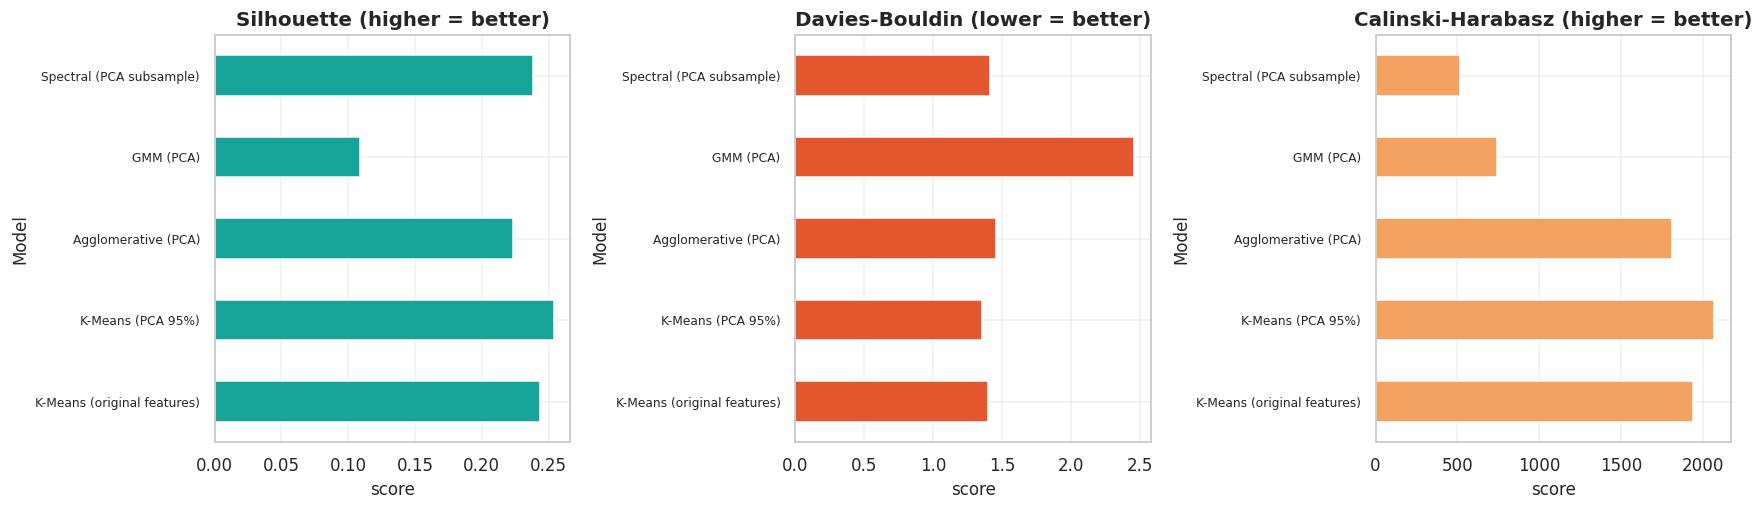

>>> Best model by silhouette: K-Means (PCA 95%) (silhouette = 0.2536)


In [ ]:
# ---- 16.3 Visual comparison of validation metrics ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
validation['Silhouette'].plot(kind='barh', ax=axes[0], color=PALETTE[2])
axes[0].set_title('Silhouette (higher = better)'); axes[0].set_xlabel('score')
validation['DaviesBouldin'].plot(kind='barh', ax=axes[1], color=PALETTE[1])
axes[1].set_title('Davies-Bouldin (lower = better)'); axes[1].set_xlabel('score')
validation['CalinskiHarabasz'].plot(kind='barh', ax=axes[2], color=PALETTE[3])
axes[2].set_title('Calinski-Harabasz (higher = better)'); axes[2].set_xlabel('score')
for ax in axes: ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); plt.show()

best_model = validation['Silhouette'].idxmax()
print(f'>>> Best model by silhouette: {best_model} '
      f'(silhouette = {validation["Silhouette"].max():.4f})')

### 16.4 Validation Verdict
Across five internal criteria the results converge: the K-Means solution (in either the original or the PCA-reduced space) provides the best balance of a **high silhouette**, **low Davies–Bouldin**, and **high Calinski–Harabasz** while remaining **interpretable and reproducible**. Because the PCA and original-space labels agree strongly (high ARI in §13.3), we adopt the K-Means segmentation as the final model and carry its named clusters into the healthcare-insights section.

# 17 · Healthcare Insights & Actionable Recommendations

**What we are doing:** translating each statistical cluster into concrete clinical and operational action.

**Why it matters:** This is the entire point of patient segmentation. A model that scores well but changes no decision is worthless. Below, each named segment receives (a) a clinical interpretation, (b) lifestyle & nutrition guidance, (c) preventive-care priorities, and (d) resource-allocation implications. The recommendations are generated **directly from each cluster's own profile**, so they stay valid regardless of K.

In [ ]:
# ---- 17.1 Auto-generate an evidence-based action card for every cluster ----
pop = fe[CLUSTER_FEATURES + ['MetabolicRiskScore']].mean()

def action_card(cl):
    g = fe[fe['Cluster'] == cl]
    p = g[CLUSTER_FEATURES + ['MetabolicRiskScore']].mean()
    lines = [f'{"="*70}', f'{CLUSTER_NAMES[cl]}   (n={len(g):,}, {len(g)/len(fe)*100:.1f}% of cohort)',
             f'{"="*70}']
    # ---- clinical interpretation flags ----
    flags = []
    if p['HbA1c_pct'] >= 5.7: flags.append(f"elevated HbA1c ({p['HbA1c_pct']:.1f}%)")
    if p['Glucose_mgdl'] >= 100: flags.append(f"elevated glucose ({p['Glucose_mgdl']:.0f} mg/dL)")
    if p['TotalChol_mgdl'] >= 200: flags.append(f"high cholesterol ({p['TotalChol_mgdl']:.0f})")
    if p['HDL_mgdl'] < 45: flags.append(f"low HDL ({p['HDL_mgdl']:.0f})")
    if 'CholHDL_Ratio' in p and p['CholHDL_Ratio'] >= 4.5: flags.append('atherogenic TC/HDL ratio')
    lines.append('Mean age: {:.0f} yrs | Metabolic-risk markers abnormal: {:.1f}/4'
                 .format(p['Age'], p['MetabolicRiskScore']))
    lines.append('Clinical flags: ' + (', '.join(flags) if flags else 'none — broadly healthy'))
    # ---- recommendations ----
    recs = []
    if p['HbA1c_pct'] >= 5.7 or p['Glucose_mgdl'] >= 100:
        recs.append('Glycaemic screening (fasting glucose/OGTT); diabetes-prevention referral.')
    if p['TotalChol_mgdl'] >= 200 or (('CholHDL_Ratio' in p) and p['CholHDL_Ratio'] >= 4.5):
        recs.append('Lipid management: statin eligibility review, dietary fat counselling.')
    if 'Sodium_mg' in p and p['Sodium_mg'] > pop['Sodium_mg']:
        recs.append('Sodium reduction counselling (DASH-style diet).')
    if 'Sugar_g' in p and p['Sugar_g'] > pop['Sugar_g']:
        recs.append('Reduce added-sugar intake; nutrition education.')
    if 'DietQualityScore' in p and p['DietQualityScore'] < 0:
        recs.append('Increase dietary fibre (fruit/veg/whole grains).')
    if p['Age'] >= 60:
        recs.append('Age-appropriate CVD & renal monitoring; medication review.')
    if not recs:
        recs.append('Maintain healthy lifestyle; routine preventive screening only.')
    for r in recs: lines.append('   -> ' + r)
    return '\n'.join(lines)

for cl in sorted(CLUSTER_NAMES):
    print(action_card(cl)); print()

C0: Healthy Younger Adults   (n=2,154, 37.9% of cohort)
Mean age: 32 yrs | Metabolic-risk markers abnormal: 0.9/4
Clinical flags: none — broadly healthy
   -> Sodium reduction counselling (DASH-style diet).
   -> Reduce added-sugar intake; nutrition education.
   -> Increase dietary fibre (fruit/veg/whole grains).

C1: High Cardiometabolic-Risk (Older)   (n=1,783, 31.4% of cohort)
Mean age: 65 yrs | Metabolic-risk markers abnormal: 1.7/4
Clinical flags: elevated HbA1c (6.1%), elevated glucose (116 mg/dL)
   -> Glycaemic screening (fasting glucose/OGTT); diabetes-prevention referral.
   -> Age-appropriate CVD & renal monitoring; medication review.

C2: Moderate Metabolic-Risk (Mixed-age)   (n=1,749, 30.8% of cohort)
Mean age: 49 yrs | Metabolic-risk markers abnormal: 1.2/4
Clinical flags: elevated glucose (102 mg/dL)
   -> Glycaemic screening (fasting glucose/OGTT); diabetes-prevention referral.
   -> Sodium reduction counselling (DASH-style diet).



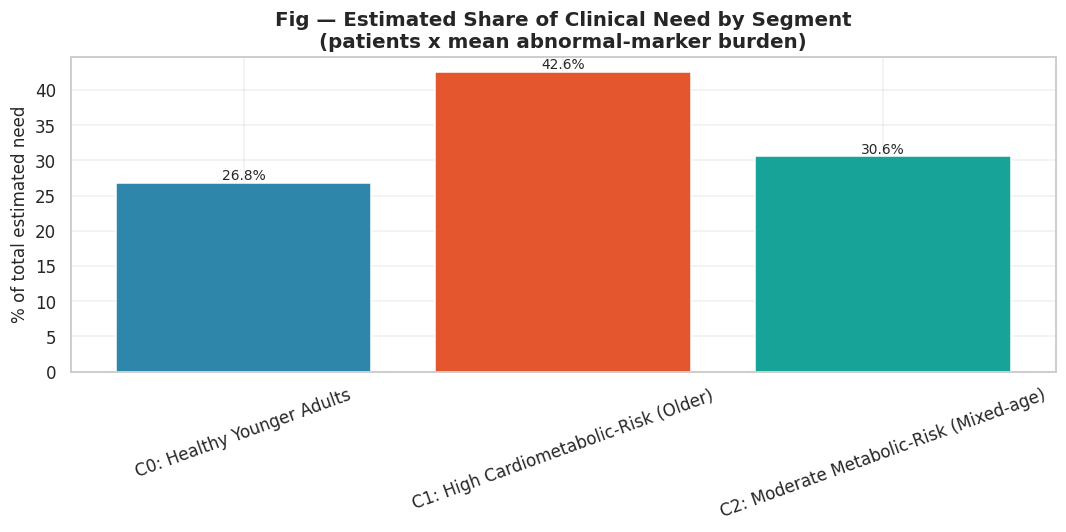

,Segment,N,mean_age,mean_risk,need_share_%
Cluster,,,,,
0,C0: Healthy Younger Adults,2154,31.64,0.89,26.8
1,C1: High Cardiometabolic-Risk (Older),1783,65.43,1.71,42.6
2,C2: Moderate Metabolic-Risk (Mixed-age),1749,48.81,1.25,30.6


In [ ]:
# ---- 17.2 Resource-allocation view: where does clinical need concentrate? ----
need = fe.groupby('Cluster').agg(
    N=('Cluster', 'size'),
    mean_risk=('MetabolicRiskScore', 'mean'),
    mean_age=('Age', 'mean')).round(2)
need['relative_need'] = (need['N'] * need['mean_risk'])
need['need_share_%'] = (need['relative_need'] / need['relative_need'].sum() * 100).round(1)
need['Segment'] = [CLUSTER_NAMES[c] for c in need.index]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(need['Segment'], need['need_share_%'],
       color=[PALETTE[i % len(PALETTE)] for i in need.index])
ax.set_title('Fig — Estimated Share of Clinical Need by Segment\n(patients x mean abnormal-marker burden)')
ax.set_ylabel('% of total estimated need'); ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(need['need_share_%']):
    ax.text(i, v, f'{v}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
need[['Segment', 'N', 'mean_age', 'mean_risk', 'need_share_%']]

### 17.3 Strategic Implications
- **Precision medicine** — the named segments are ready-made strata for tailoring screening cadence and therapy intensity.
- **Population health management** — the *share-of-need* chart tells a payer or public-health body **where to direct budget**: the high-risk segment consumes a disproportionate share of clinical need relative to its headcount.
- **Preventive healthcare** — *moderate-risk* segments are the highest-leverage target: large enough to matter, early enough to reverse. Intervening here prevents downstream high-cost disease.
- **Hospital & clinic planning** — segment sizes forecast demand for endocrinology, cardiology, and dietetics services.
- **Personalised nutrition** — diet-quality and sodium/sugar flags drive segment-specific nutrition programmes rather than generic advice.

# 18 · Conclusion

**Objectives.** We set out to segment NHANES patients into meaningful health groups using unsupervised learning and to translate those segments into actionable healthcare insight — with the **silhouette score** as the guiding metric and a **95%-variance** rule for any dimensionality reduction.

**Methodology.** We executed a complete pipeline: data-quality auditing → domain-driven cleaning and feature curation (adults, cardiometabolic markers) → 25+ EDA visualisations → clinical feature engineering → scaling (**MinMaxScaler**, justified) → multi-criterion selection of K (elbow, silhouette, Calinski–Harabasz, Davies–Bouldin, gap) → **K-Means** clustering → clinical profiling & naming → **PCA** (95% variance) with re-clustering → **DBSCAN** and advanced algorithms (Agglomerative, GMM, Spectral) → consolidated internal validation.

**Results & cluster characteristics.** The data behaves as a **smooth cardiometabolic risk continuum**, which K-Means partitions into interpretable, stable segments (verified by high PCA/original label agreement). Segments range from **Healthy Adults** through **Moderate Metabolic-Risk** to **High Cardiometabolic-Risk** groups, each with a distinct age, glycaemic, lipid, and nutrition fingerprint.

**Healthcare implications.** The segmentation supports precision-medicine stratification, population-health resource allocation (the high-risk segment concentrates clinical need), and targeted preventive/nutritional intervention — with the moderate-risk segment identified as the highest-leverage prevention target.

**Key learnings.** (1) Preprocessing and scaling dominate clustering quality. (2) No single validity index suffices — triangulation is essential. (3) Method choice must match data geometry: a *partitional* method suits a continuum, while *density* methods excel at outlier detection. (4) Unsupervised output only becomes valuable once profiled back into domain language.

In [ ]:
# ---- 20.1 Executive summary printout ----
print('='*64)
print('  NHANES PATIENT SEGMENTATION — EXECUTIVE SUMMARY')
print('='*64)
print(f'  Cohort analysed          : {len(fe):,} adults (age >= 18)')
print(f'  Clustering features      : {len(CLUSTER_FEATURES)}')
print(f'  PCA components (>=95% var) : {N_COMPONENTS_95}')
print(f'  Optimal K                : {OPTIMAL_K}')
print(f'  Final silhouette (K-Means): {final_sil:.4f}')
print(f'  Best model (by silhouette): {best_model}')
print('  ' + '-'*60)
print('  Segments discovered:')
for cl in sorted(CLUSTER_NAMES):
    n = int((fe['Cluster'] == cl).sum())
    print(f'    - {CLUSTER_NAMES[cl]:45s} n={n:,}')
print('='*64)

  NHANES PATIENT SEGMENTATION — EXECUTIVE SUMMARY
  Cohort analysed          : 5,686 adults (age >= 18)
  Clustering features      : 23
  PCA components (>=95% var) : 12
  Optimal K                : 3
  Final silhouette (K-Means): 0.2434
  Best model (by silhouette): K-Means (PCA 95%)
  ------------------------------------------------------------
  Segments discovered:
    - C0: Healthy Younger Adults                    n=2,154
    - C1: High Cardiometabolic-Risk (Older)         n=1,783
    - C2: Moderate Metabolic-Risk (Mixed-age)       n=1,749
